# Live Phishing URL Recognition System

## Introduction
In today’s digital age, cybersecurity is more critical than ever. Among the various types of cyberattacks, **phishing** remains the most prevalent and effective. In fact, phishing is responsible for *over 36% of all data breaches in 2025* alone, making it a top threat across industries. According to the latest [TechMagic](https://www.techmagic.co/blog/blog-phishing-attack-statistics) report, phishing attacks caused global damages exceeding $12.5 billion in 2024, marking a 25% year-over-year increase. And not only that, AI is enabling faster, more personalized data-stealing malware, spear phishing emails, and phishing sites. By 2027, AI is predicted to be involved in 17% of cyberattacks. 

These attacks are not just increasing in frequency, they're becoming more sophisticated. [Hoxhunt's 2025 phishing trends report](https://hoxhunt.com/guide/phishing-trends-report#part-i-phishing-trends-amp-statistics) has revealed that attackers are now leveraging AI to craft hyper-realistic messages and domains, drastically increasing click-through and deception rates. In fact, phishing emails are now intercepted every 42 seconds, and 66% of all phishing emails are specifically targeted at business users.

It becomes natural to ask ourselves, *why does phishing matter more now than ever*? And we can list some reasons:
- **Rapid evolution of phishing tactics**: Attackers now use AI to personalize messages, making them nearly indistinguishable from legitimate sources.
- **Business Email Compromise (BEC)**: Targeted attacks impersonating executives are increasingly common, with financial losses often exceeding millions of dollars.
- **Economic and reputational damage**: The average cost of a phishing-related breach in the U.S. reached $4.9 million in 2024 [source].

And last, but not least...
- **AI vs. AI**: As threat actors adopt AI tools, we must deploy intelligent countermeasures, in fact this project is designed as a proactive shield, not a reactive patch.

## Goal
To address the steadily growing threat of phishing, we wanted to develop a **live phishing URL recognition system** using machine learning models for **URL classification**. We also had the goal to provide a solution that by design could be easily embedded within browsers, email clients, or enterprise-grade cybersecurity tools, and that could possibly be used to expand the dataset to obtain an extended and much more fine-grained classifier to tackle the increasing complexity and evolution of phishing tactics. 

## Specifics
To achieve this goal, we used a dataset that was constructed based on a [research group paper](https://eprints.hud.ac.uk/id/eprint/24330/6/MohammadPhishing14July2015.pdf) published by University of Huddersfield, which highlights and explains the reasoning behind important features that can be extracted from URLs to be able to detect phishing behavior. 

# Setting Up

In [1]:
# Standard library
import re
import math
import socket
import base64
import hashlib
import logging
import warnings
from datetime import datetime

# Third-party libraries
import pandas as pd
import numpy as np
import requests
import whois
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# Data processing & transformation
from urllib.parse import urlparse
from scipy.io import arff
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

# Models
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm

# Utilities
from sklearn.exceptions import NotFittedError


# Data Acquisition

The dataset is saved in an .ARFF format. Therefore, we load it and proceed with the exploration and preprocessing of the set.

In [2]:
# dataset load ARFF
data = arff.loadarff('Training Dataset.arff')

# training set var is initialized 
train_arff = pd.DataFrame(data[0])

# Data Exploration and Preprocessing

We take a look at the structure of the dataset, and at the first 10 entries to visually check on the data.

In [3]:
train_arff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   having_IP_Address            11055 non-null  object
 1   URL_Length                   11055 non-null  object
 2   Shortining_Service           11055 non-null  object
 3   having_At_Symbol             11055 non-null  object
 4   double_slash_redirecting     11055 non-null  object
 5   Prefix_Suffix                11055 non-null  object
 6   having_Sub_Domain            11055 non-null  object
 7   SSLfinal_State               11055 non-null  object
 8   Domain_registeration_length  11055 non-null  object
 9   Favicon                      11055 non-null  object
 10  port                         11055 non-null  object
 11  HTTPS_token                  11055 non-null  object
 12  Request_URL                  11055 non-null  object
 13  URL_of_Anchor                11

In [4]:
train_arff.head(10)

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'
5,b'-1',b'0',b'-1',b'1',b'-1',b'-1',b'1',b'1',b'-1',b'1',...,b'1',b'1',b'1',b'1',b'1',b'-1',b'1',b'-1',b'-1',b'1'
6,b'1',b'0',b'-1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'0',b'-1',b'-1'
7,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'0',b'1',b'-1'
8,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'1',b'1',b'0',b'1',b'1'
9,b'1',b'1',b'-1',b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'0',b'-1',b'1',b'0',b'1',b'-1'


What we can see here is that the dataset has a **categorical** description of the features. Here we have 30 distinct features and a Result column that is going to be used for the classification process as it highlight the status of the URL entry that is being described. 

The dataset presents its data in a binary format, but what we can see, and confirm by looking at the paper that came with the dataset, is that the features are being described with a ternary classification: 

- Value 1: Legitimate URL
- Value -1: Phishing URL
- (Optional Value 0): Suspicious URL

It's important to notice that not every feature of the set includes the "suspicious" status, it depends on the feature that it's being described by the column. We can make an example by confronting the *"URL_length"* feature with the *"having_IP_Address"* one:

- **URL_length**: Phishers can use long URL to hide the doubtful part in the address bar. The paper declares that: 
    - length < 54: Legitimate
    - 54 <= lentgh <= 74: Suspicious
    - length < 74: Phishing
- **having_IP_Address**: If an IP address is used as an alternative of the domain name in the URL, such as “http://125.98.3.123/fake.html”, users can be sure that someone is trying to steal their personal information. The paper declares that:
    - Domain has ip address: Phishing
    - Otherwise: Legitimate

Therefore, we proceed to convert the data from **binary**, to **string**, and then to **integers**. Lastly, we save the polished set into a CSV file, which is a much more supported format for machine learning techniques. 

In [5]:
# for loop to decode from binary to char (utf8)
for col in train_arff.columns:
    if train_arff[col].dtype == object:
        train_arff[col] = train_arff[col].map(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# for loop to encode from char (utf8) to INT
for col in train_arff.columns:
    try:
        train_arff[col] = train_arff[col].astype(int)
    except ValueError:
        print(f"Column '{col}' not convertible as an Int value")

# create CSV from polished ARFF
train_arff.to_csv('./TrainingDataset.csv', index=False)
train_arff.head(10)

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,-1,1,0,-1,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,0,-1,1,0,1,-1
8,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,-1,1,1,1,0,1,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,0,-1,1,0,1,-1


We load the polished dataset from the CSV file, and check that everything has been loaded just fine. 

In [6]:
train = pd.read_csv('./TrainingDataset.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

In [7]:
train.head(10)

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
5,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1
6,1,0,-1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,-1,1,0,-1,-1
7,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,0,-1,1,0,1,-1
8,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,1,-1,1,1,1,0,1,1
9,1,1,-1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,0,-1,1,0,1,-1


In [8]:
print(train.dtypes)

having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                      int64
G

We now proceed to make some basic check onto the dataset:

1) Check for missing values.
2) Check for hidden non-numeric values.

In [9]:
# Check for missing values
print(train.isnull().sum())

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [10]:
# Check for hidden non-numeric values
print(train.apply(lambda x: x.unique()))

having_IP_Address                 [-1, 1]
URL_Length                     [1, 0, -1]
Shortining_Service                [1, -1]
having_At_Symbol                  [1, -1]
double_slash_redirecting          [-1, 1]
Prefix_Suffix                     [-1, 1]
having_Sub_Domain              [-1, 0, 1]
SSLfinal_State                 [-1, 1, 0]
Domain_registeration_length       [-1, 1]
Favicon                           [1, -1]
port                              [1, -1]
HTTPS_token                       [-1, 1]
Request_URL                       [1, -1]
URL_of_Anchor                  [-1, 0, 1]
Links_in_tags                  [1, -1, 0]
SFH                            [-1, 1, 0]
Submitting_to_email               [-1, 1]
Abnormal_URL                      [-1, 1]
Redirect                           [0, 1]
on_mouseover                      [1, -1]
RightClick                        [1, -1]
popUpWidnow                       [1, -1]
Iframe                            [1, -1]
age_of_domain                     

Up to this point the dataset appears to be in a good shape, it doesn't contain any unexpected values and it corresponds to what we were expecting from the dataset paper. 

We now proceed to take a look at the **Result target** class to look at the distribution of the Phishing/Legitimate URLs, and see if there is the necessity to apply some balancing technique.

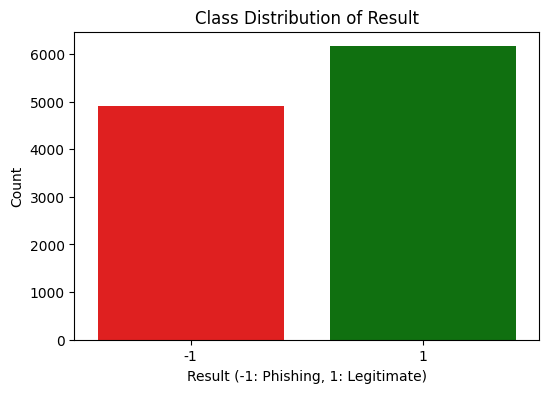

In [11]:
# Plot class distribution
custom_palette = {-1: 'red', 1: 'green'}
logging.getLogger('matplotlib.category').setLevel(logging.ERROR)

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='Result', hue='Result', palette=custom_palette, legend=False)
plt.title('Class Distribution of Result')
plt.xlabel('Result (-1: Phishing, 1: Legitimate)')
plt.ylabel('Count')
#plt.tight_layout()
plt.show()

As it can be seen from the plot, the entire dataset has a quite strong balance between the two classes.

Now we proceed to split the dataset into X (dataframe with the features) and y (a column array with the Result target class), to proceed to do some *feature analysis*.

In [12]:
# Features and target
X = train.drop(columns=["Result"])
y = train["Result"]

# popUpWindow has a misspelt name
X.rename(columns={'popUpWidnow': 'popUpWindow'}, inplace=True)

We proceed to do some Feature Analysis. 

The first thing we look at is the **Cramer's V Heatmap**. The main intent is to possibly identify redundant categorical features that are highly correlated with each other.  

We decided to use this type of heatmap because the dataset is entirely made of categorical features. Hence, Cramer's V is useful for visualising the strength of association between pairs of categorical variables in the dataset. Each cell of the map will represent a value between 0 (no association) and 1 (high correlation), and it will describe the strength between any two pairs of categorical features of the set.  

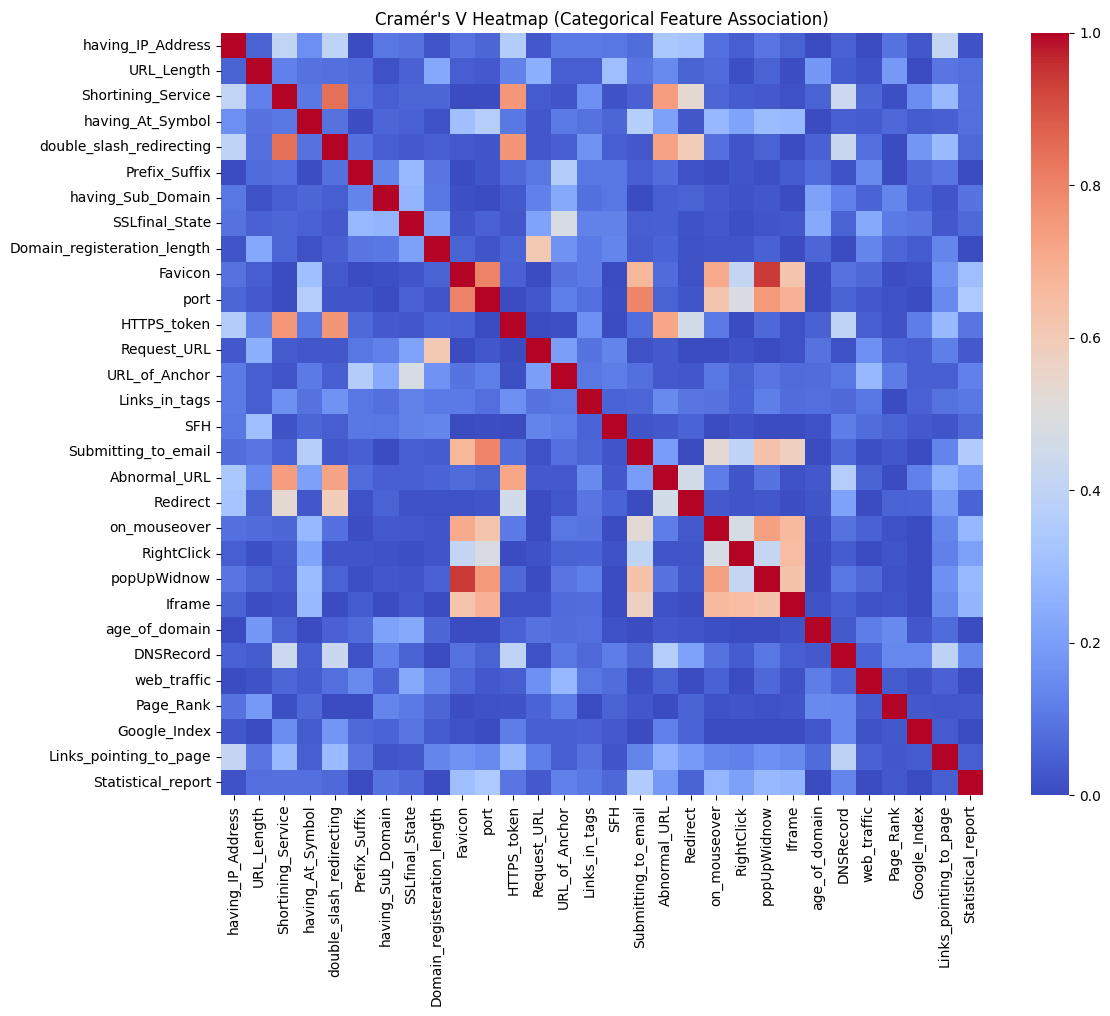

In [13]:
# Cramer's V Heatmap (feature-to-feature associations)

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.size == 0:
        return np.nan  # no valid data
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Load Phishing Categories
categorical_cols = train.drop(columns=['Result']).columns

# Create matrix
cramers_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        val = cramers_v(train[col1], train[col2])
        cramers_matrix.loc[col1, col2] = val

# Convert to float
cramers_matrix = cramers_matrix.astype(float)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_matrix, cmap="coolwarm", annot=False, square=True)
plt.title("Cramér's V Heatmap (Categorical Feature Association)")
plt.tight_layout()
plt.show()

As we can see from the heatmap, the features appear to be strongly uncorrelated with each other. The only case of a higher level of correlation is found between the **popUpWindow** and **Favicon** features.

In [14]:
# Find the pair with the highest Cramér's V (excluding diagonal)
mask = np.triu(np.ones(cramers_matrix.shape), k=1).astype(bool)
max_val = cramers_matrix.where(mask).max().max()
max_pair = cramers_matrix.where(mask).stack().idxmax()

print(f"\n-> Highest Cramér's V: {max_val:.3f} between features: {max_pair}")

# Suggested feature to drop
feature_to_drop = max_pair[1]
print(f"-> Suggested feature to drop: {feature_to_drop}")


-> Highest Cramér's V: 0.939 between features: ('Favicon', 'popUpWidnow')
-> Suggested feature to drop: popUpWidnow


Before proceeding with the dropping of the **popUpWindow** feature, we want to look at the feature-to-feature importance by plotting the **Mutual Information Heatmap**. This heatmap measures information gain between features and the target, and it's great to understand which features are informative for classification. 

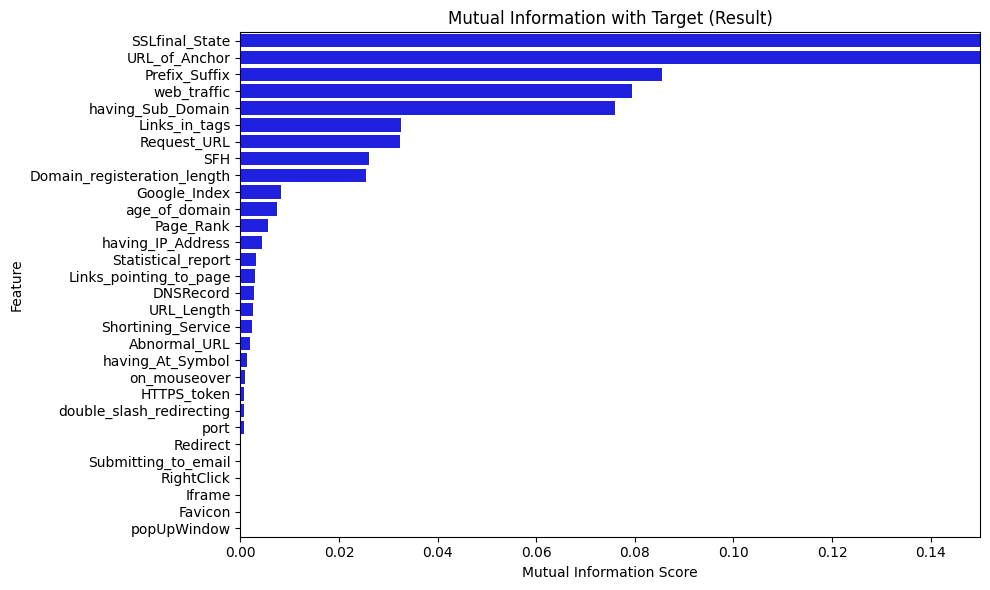

In [15]:
# Mutual Information Heatmap (feature-to-target importance)
'''
Entropy estimation from k-nearest neighbours distances.
'''

# Compute mutual information
mi_scores = mutual_info_classif(X, y, discrete_features=True)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.xlim(0,0.15)
sns.barplot(x=mi_series.values, y=mi_series.index, color="blue")
plt.title("Mutual Information with Target (Result)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

We can see that **popUpWindow** and **Favicon** are at the bottom of the table, meaning their contribution to the target column is extremely low. There is also a group of features (**Redirect, Submitting_to_email, RightClick, iFrame**) that present the same information result as the previous two mentioned. 

We decided to drop **popUpWindow**, given the correlation results with Favicon, and maintain this last one as well as all of the other features mentioned. That is done because we consider our dataset to have a limited number of features and we want, in this playground, to proceed training different classification models with the most features possible.

In [16]:
# popUpWindow drop
X = X.drop(columns=['popUpWindow'])

# Shape of the DataFrame
print("Shape of X:", X.shape)

# Columns in X
print("Columns in X:", X.columns.tolist())

Shape of X: (11055, 29)
Columns in X: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


# Data Processing

## Introduction
Our main goal is to develop a Live URL Phishing Recognition System. Hence, in this Data Processing phase, we proceed to train and evaluate different machine learning classification models, with the objective of understanding which is the most performant one, and apply that for the live detection system. 

We decided to train 4 different models: 

- **Decision Tree Family**: These can model complex interactions between features, and are great at handling categorical data. Moreover, in the case of our dataset, there is no need for feature scaling or encoding.
    - 1) **Decision Tree Classifier**: It handles categorical data natively, is interpretable and captures non-linear relationships. For categorical features, it evaluates each possible split (e.g., having_IP_Address = -1, 0, or 1) and chooses the one that best separates the classes.
      2) **Random Forest Classifier**: It's very well-suited for categorical datasets, like ours, and for classification tasks. Phishing behaviour often involves complex combinations of features (e.g., short URLs and missing SSL certificates), and a Random Forest can model these interactions naturally by building diverse trees that explore different combinations. It doesn't assume independence or linearity, which is ideal for categorical features. Also, Random Forests are consistently among the top-performing models in classification tasks with categorical features, and that's also why we wanted to include it in our data processing phase.


- **Naive Bayesian (Categorical)**: We use this version of the Naive Bayesian as it's specifically designed for features that are described with discrete values, i.e. categories like ours.
  
- **Logistic Regression**: We pair it with OneHot Encoding. This allows the model to learn a linear relationship between these binary indicators and the log-odds of the Result target class. It’s useful in URL Phishing detection because it provides interpretable coefficients, fast training, and reliable probability estimates. It’s also a strong benchmark to compare other models against it.

For each model, we decided to proceed with the evaluation of the following metrics:

- An overall evaluation of the prediction capabilities of the model: **Precision, Recall, F1-Score and Accuracy**. Given that the F1-Score is the harmonic mean of the precision and recall estimates, we will evaluate our models on the F1-Score and Accuracy results. This is also going to be useful later on for the T-Testing of the two-best classifiers. 
- **Confusion Matrix**: to understand how well our model is performing. w.r.t. the prediction outcomes.
- **ROC Curve**: to visualise the trade-off between catching positives and avoiding false alarms (True Positive Rate (TPR), False Positive Rate (FPR))
- **Legitimate Class Probability Distribution**: to see how the model's predicted probabilities differ between the two classes.
- **Cross Validation**(stratified-10-folds): to obtain confirmation on these results, to ensure that each fold roughly has the same class distribution as the whole dataset, and to have a more reliable and stable estimate of our model’s performance.


## Preparation

Now the X and y are going to be split in train and test data in a proportion of 20% of the entire dataset used as test for the models and the remaining 80% used to train the models.

In [17]:
# X, y were already prepared for the Feature Analysis

# So we: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# And prepare for Cross Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

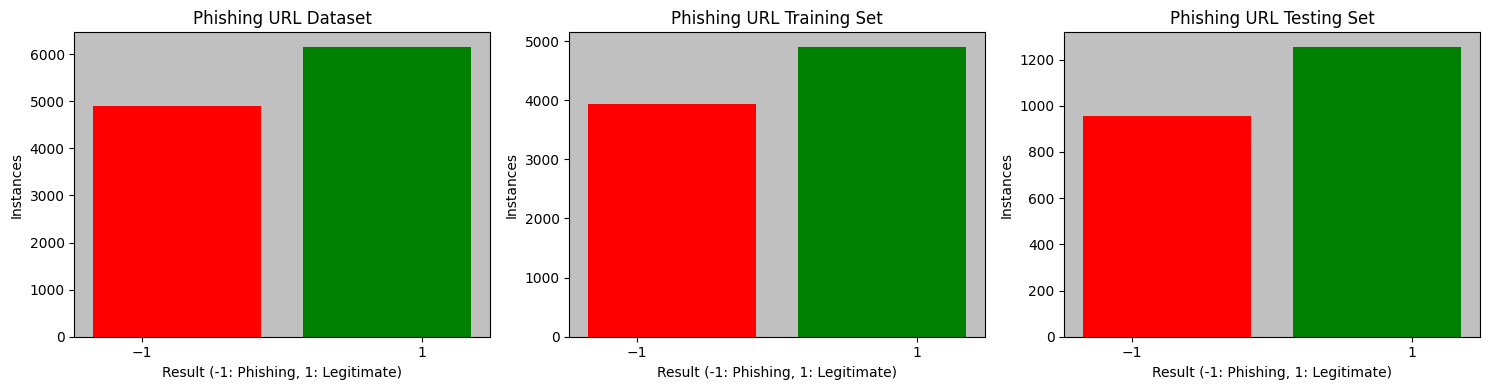

In [18]:
# And take a look at the phishing/legitimate distribution of the dataset, the training set and testing set

# Define bins and class-specific colors
bins = [-1.5, 0, 1.5]
xticks = [-1, 1]
colors = {-1: 'red', 1: 'green'}

fig, graph = plt.subplots(1, 3, figsize=(15, 4))

# First: Full dataset
graph[0].set_title('Phishing URL Dataset')
for label in [-1, 1]:
    graph[0].hist(y[y == label], bins=bins, color=colors[label], rwidth=0.8, label=f"Class {label}")
graph[0].set_xlabel('Result (-1: Phishing, 1: Legitimate)')
graph[0].set_xticks(xticks)
graph[0].set_ylabel('Instances')
graph[0].set_facecolor('silver')

# Second: Training set
graph[1].set_title('Phishing URL Training Set')
for label in [-1, 1]:
    graph[1].hist(y_train[y_train == label], bins=bins, color=colors[label], rwidth=0.8, label=f"Class {label}")
graph[1].set_xlabel('Result (-1: Phishing, 1: Legitimate)')
graph[1].set_xticks(xticks)
graph[1].set_ylabel('Instances')
graph[1].set_facecolor('silver')

# Third: Testing set
graph[2].set_title('Phishing URL Testing Set')
for label in [-1, 1]:
    graph[2].hist(y_test[y_test == label], bins=bins, color=colors[label], rwidth=0.8, label=f"Class {label}")
graph[2].set_xlabel('Result (-1: Phishing, 1: Legitimate)')
graph[2].set_xticks(xticks)
graph[2].set_ylabel('Instances')
graph[2].set_facecolor('silver')

plt.tight_layout()
plt.show()

This graphic shows and confirms again that all sets are balanced between phishing and legitimate values.

## Decision Tree Models

### Decision Tree

#### Model

In [19]:
# Initialize 
modelDT = DecisionTreeClassifier(random_state=42)

modelDT.fit(X_train, y_train)
y_pred_dt = modelDT.predict(X_test)
y_proba_dt = modelDT.predict_proba(X_test)[:, 1]

print("=== Decision Tree Report ===")
print(classification_report(y_test, y_pred_dt))

# save the model for live analysis
joblib.dump(modelDT, "models/phishing_model_dt.pkl");

=== Decision Tree Report ===
              precision    recall  f1-score   support

          -1       0.95      0.95      0.95       956
           1       0.96      0.96      0.96      1255

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



#### Plotting

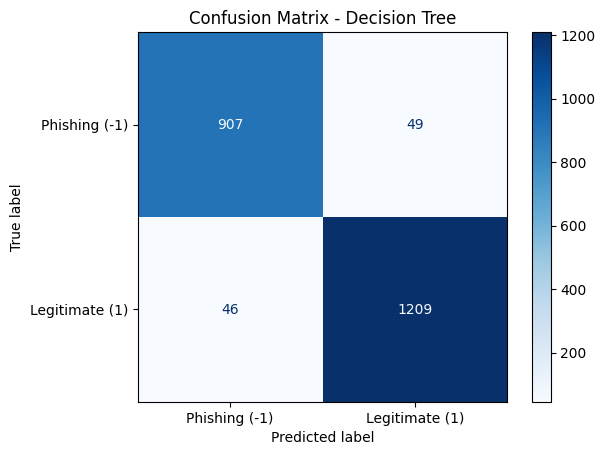

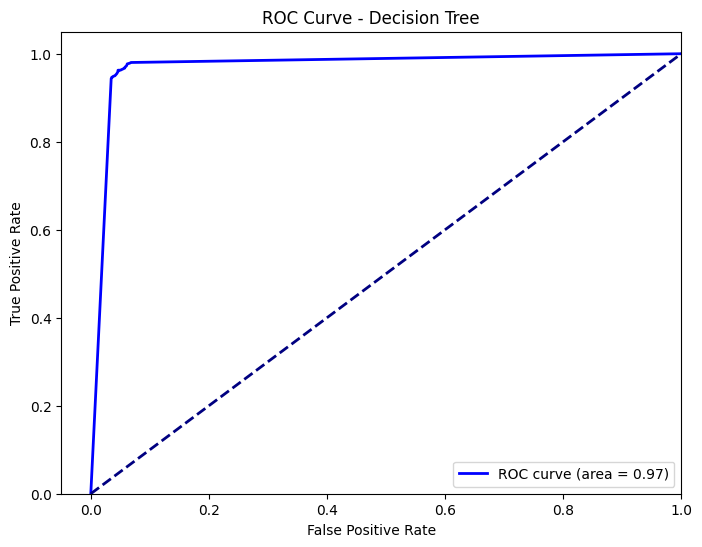

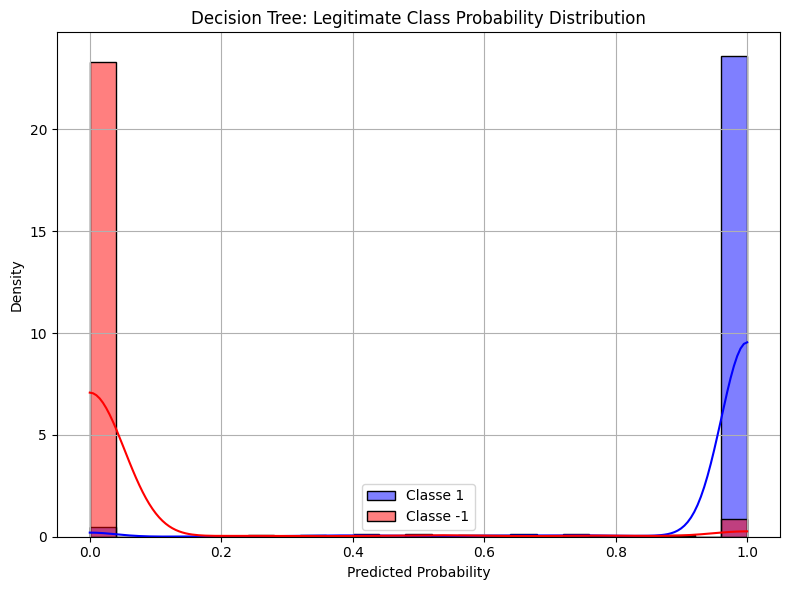

In [20]:
# Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt, labels=[-1, 1])
disp_nb = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_dt, display_labels=["Phishing (-1)", "Legitimate (1)"])

disp_nb.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.grid(False)
plt.show()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(y_proba_dt[y_test == 1], bins=25, color='blue', label='Classe 1', stat='density', kde=True)
sns.histplot(y_proba_dt[y_test == -1], bins=25, color='red', label='Classe -1', stat='density', kde=True)
plt.title('Decision Tree: Legitimate Class Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Decision Tree performance appears to be quite strong as we have an F1-Score of (0.95, 0.96) for the two classes, and an accuracy estimate of (0.96). The confusion matrix shows that the model correctly classifies both phishing and legitimate emails with high accuracy, as the misclassifications (49 false positives and 46 false negatives) are relatively low. The ROC Curve has an AUC of (0.97) which indicates great discriminative ability. The probability distibution also confirms that the model is very confident in its predictions, which suggests it’s not confused by borderline cases, even though they still appear. 

We proceed with the cross-validation of the model to confirm these results.

#### Decision Tree Cross Validated

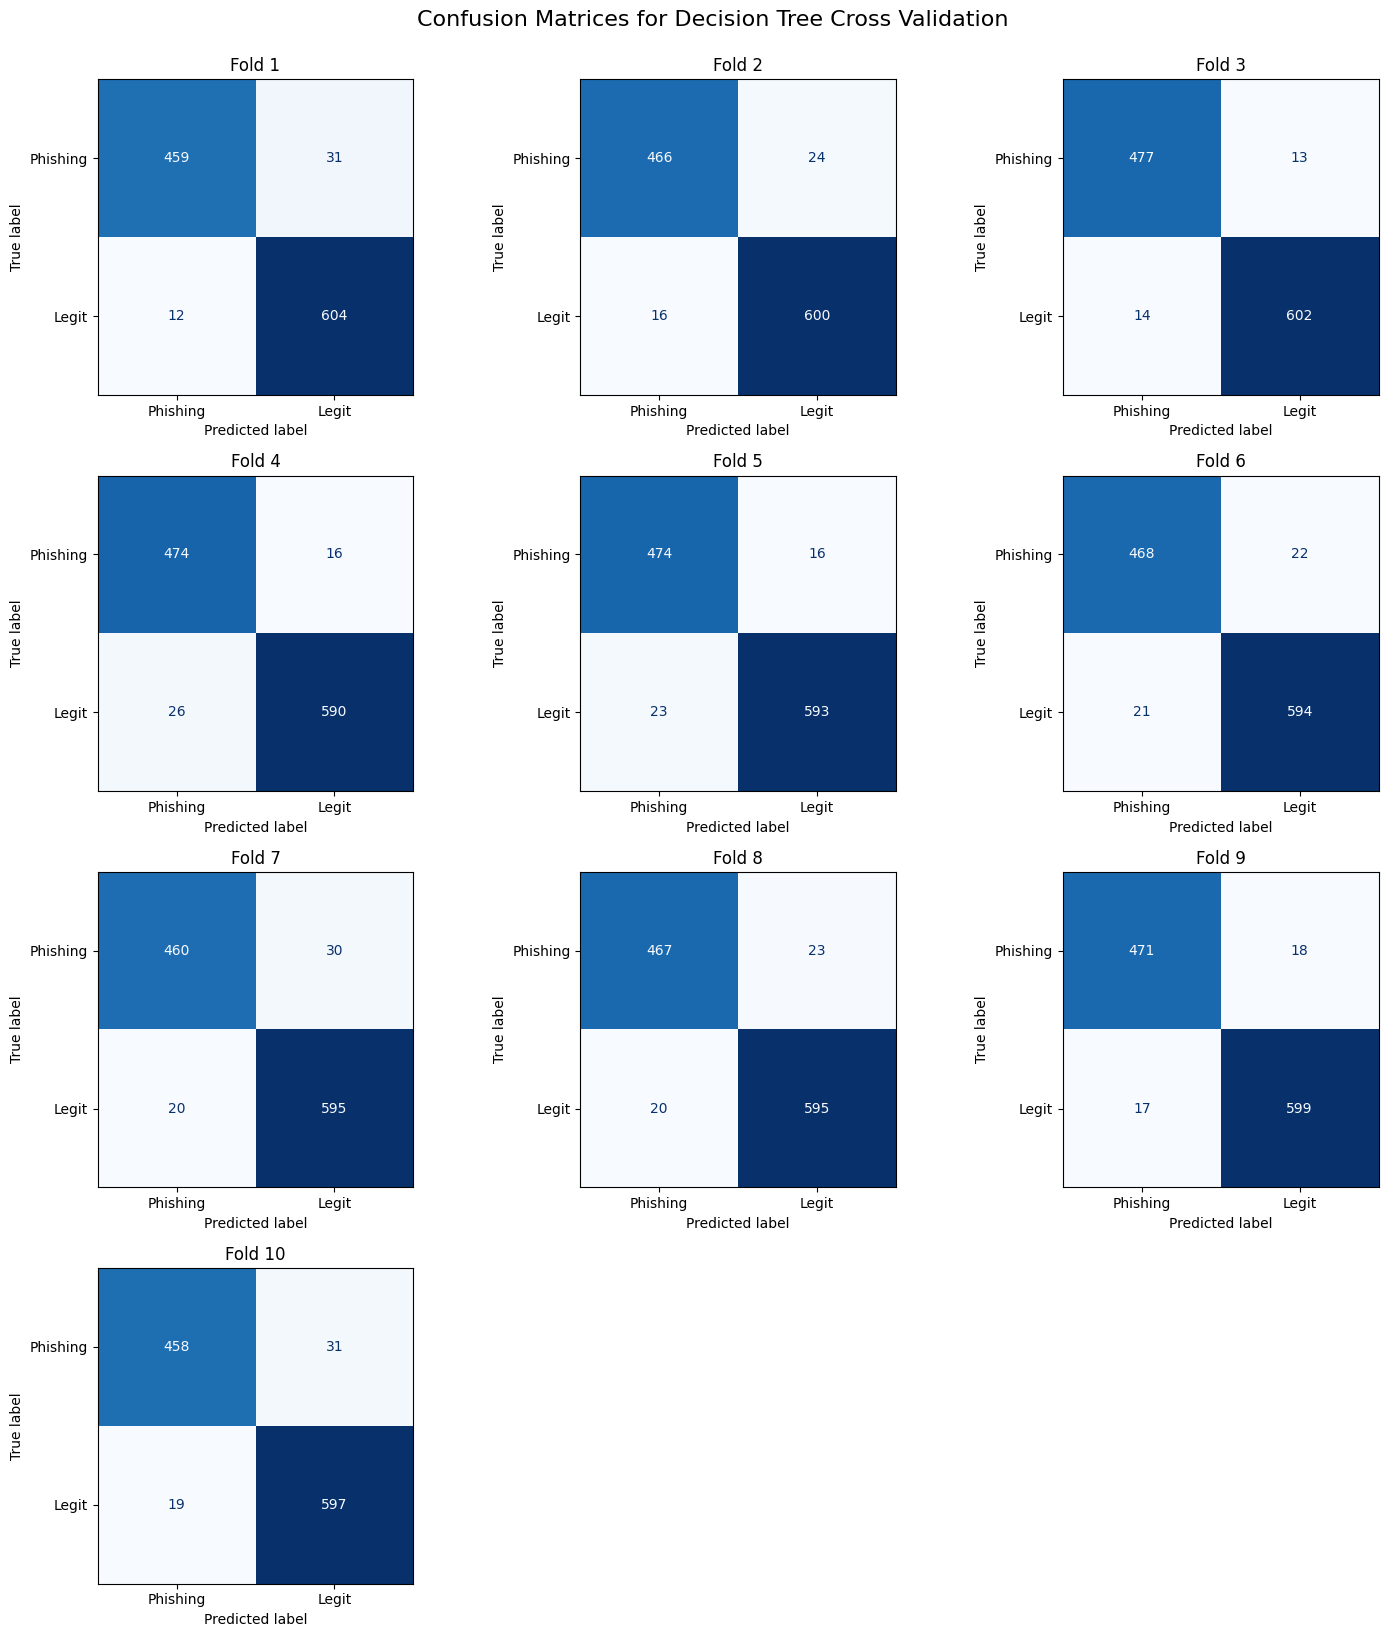

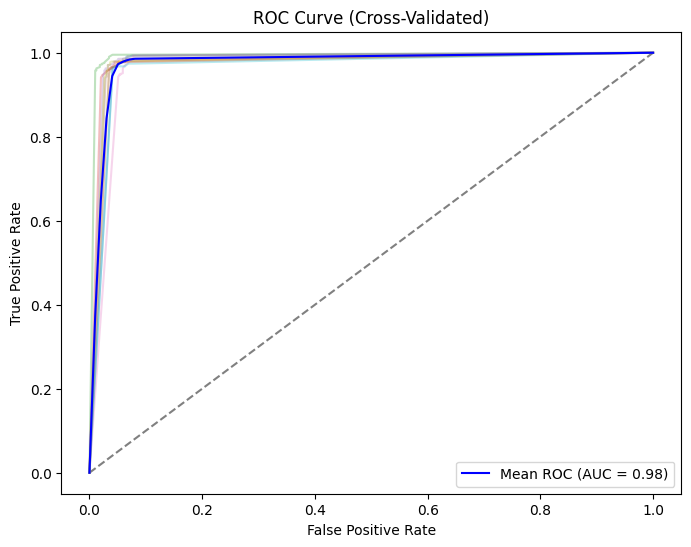


=== Decision Tree Cross-Validated Metrics (Mean over Folds) ===
Average Accuracy:  0.9627

=== Average Per-Class Metrics (Cross-Validated) ===

Class -1 (Phishing):
  Avg Precision: 0.9614
  Avg Recall   : 0.9543
  Avg F1-score : 0.9578

Class 1 (Legit):
  Avg Precision: 0.9639
  Avg Recall   : 0.9695
  Avg F1-score : 0.9667



In [21]:
# --- (Gaussian + Cross Validation) with OneHot Encoding
accuracy_dt_list = []
precision_dt_list = []
recall_dt_list = []
f1_dt_list = []

# Manually collect per-class metrics during CV
from collections import defaultdict
class_metrics = defaultdict(list)

# Plot settings
n_folds = skf.get_n_splits()
cols = 3
rows = math.ceil(n_folds / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[val_idx]

    modelDT.fit(X_train_fold, y_train_fold)
    y_pred_dt_fold = modelDT.predict(X_test_fold)
    
   # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred_dt_fold)
    prec = precision_score(y_test_fold, y_pred_dt_fold)
    rec = recall_score(y_test_fold, y_pred_dt_fold)
    f1 = f1_score(y_test_fold, y_pred_dt_fold, average='macro')
    
    accuracy_dt_list.append(acc)
    precision_dt_list.append(prec)
    recall_dt_list.append(rec)
    f1_dt_list.append(f1)

    # Reporting the Fold
    report = classification_report(y_test_fold, y_pred_dt_fold, output_dict=True)
    for label in ['-1', '1']:  # string keys for labels
        for metric in ['precision', 'recall', 'f1-score']:
            class_metrics[(label, metric)].append(report[label][metric])


    # Plot confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred_dt_fold, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legit'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices for Decision Tree Cross Validation", fontsize=16, y=1.02)
plt.show()

# ROC Curve
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8,6))

# Get index of class 1 in the columns of predict_proba
positive_class_index = list(modelDT.classes_).index(1)

for trainRoc, test in skf.split(X, y):
    modelDT.fit(X.iloc[trainRoc], y.iloc[trainRoc])
    probas_ = modelDT.predict_proba(X.iloc[test])
    fpr, tpr, thresholds = roc_curve(y.iloc[test], probas_[:, positive_class_index])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Cross-Validated)')
plt.legend()
plt.show()

# --- Print average metrics ---
print("\n=== Decision Tree Cross-Validated Metrics (Mean over Folds) ===")
print(f"Average Accuracy:  {sum(accuracy_dt_list) / len(accuracy_dt_list):.4f}")
print()

print("=== Average Per-Class Metrics (Cross-Validated) ===")
for label in ['-1', '1']:
    print(f"\nClass {label} ({'Phishing' if label == '-1' else 'Legit'}):")
    for metric in ['precision', 'recall', 'f1-score']:
        values = class_metrics[(label, metric)]
        mean_val = sum(values) / len(values)
        print(f"  Avg {metric.capitalize():<9}: {mean_val:.4f}")
print()


The Decision tree Cross-validated metrics are *slightly* better overall, particularly in precision and F1-score, suggesting the model performs consistently well and confirming the previous results. 

### Random Forest

#### Model

In [22]:
# Initialize 
modelRF = RandomForestClassifier(random_state=42)

modelRF.fit(X_train, y_train)
y_pred_rf = modelRF.predict(X_test)
y_proba_rf = modelRF.predict_proba(X_test)[:, 1]

print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

# save the model for live analysis
joblib.dump(modelRF, "models/phishing_model_rf.pkl");

=== Random Forest Report ===
              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.96      0.97      2211
weighted avg       0.97      0.97      0.97      2211



#### Plotting

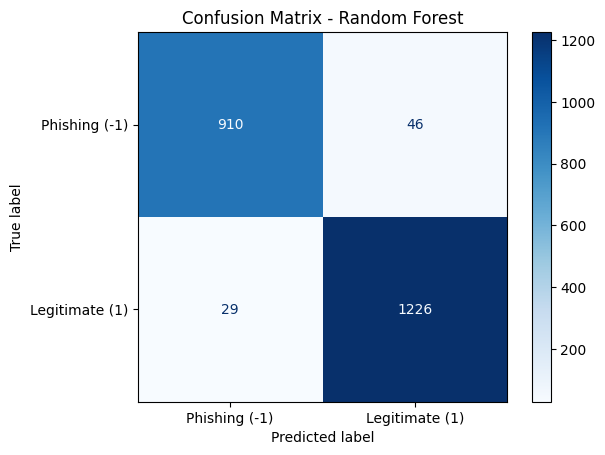

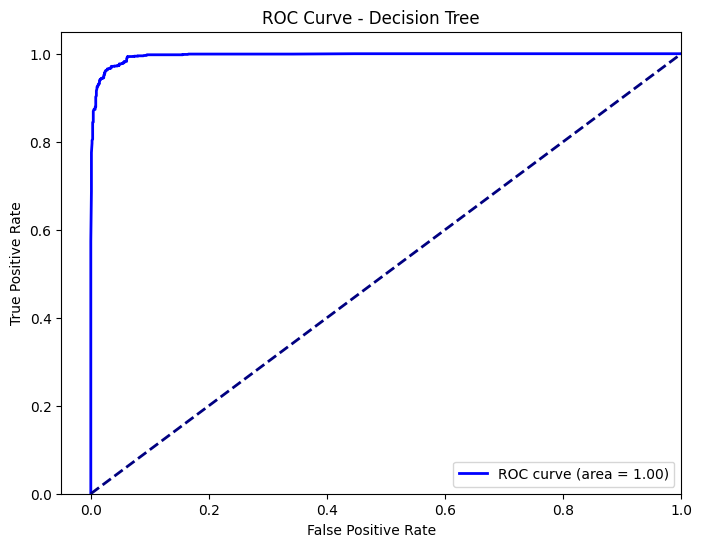

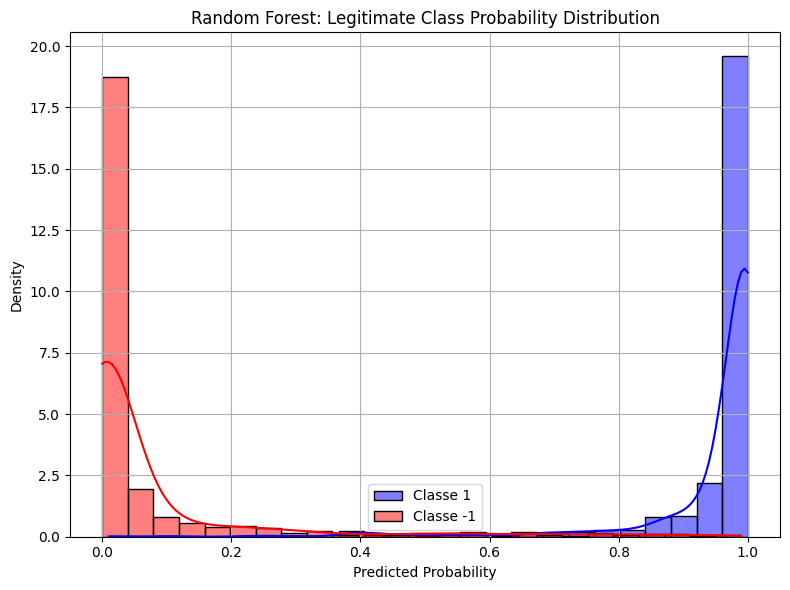

In [23]:
# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=["Phishing (-1)", "Legitimate (1)"])

disp_rf.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.show()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(y_proba_rf[y_test == 1], bins=25, color='blue', label='Classe 1', stat='density', kde=True)
sns.histplot(y_proba_rf[y_test == -1], bins=25, color='red', label='Classe -1', stat='density', kde=True)
plt.title('Random Forest: Legitimate Class Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Random Forest performance appears to be even stronger than the Decision Tree model, as we have an F1-Score of (0.96, 0.97) for the two classes, and an overall accuracy estimate of (0.97). The confusion matrix shows that the model correctly classifies both phishing and legitimate emails with very high precision, as the number of misclassifications is low: 46 false positives and only 29 false negatives. The ROC Curve has an AUC of (1.00), which indicates near-perfect discriminative ability. The model distinguishes with great precision between the two classes. The probability distribution also reinforces this strength: the model shows extreme confidence in its predictions, with class probabilities sharply concentrated near 0 and 1. Like the Decision Tree, the Random Forest model isn’t confused by borderline cases, but presents even more decisive class separation, suggesting a more robust decision boundary than the previous model.

We proceed with the cross-validation of the model to confirm these results.

#### Random Forest Cross Validated

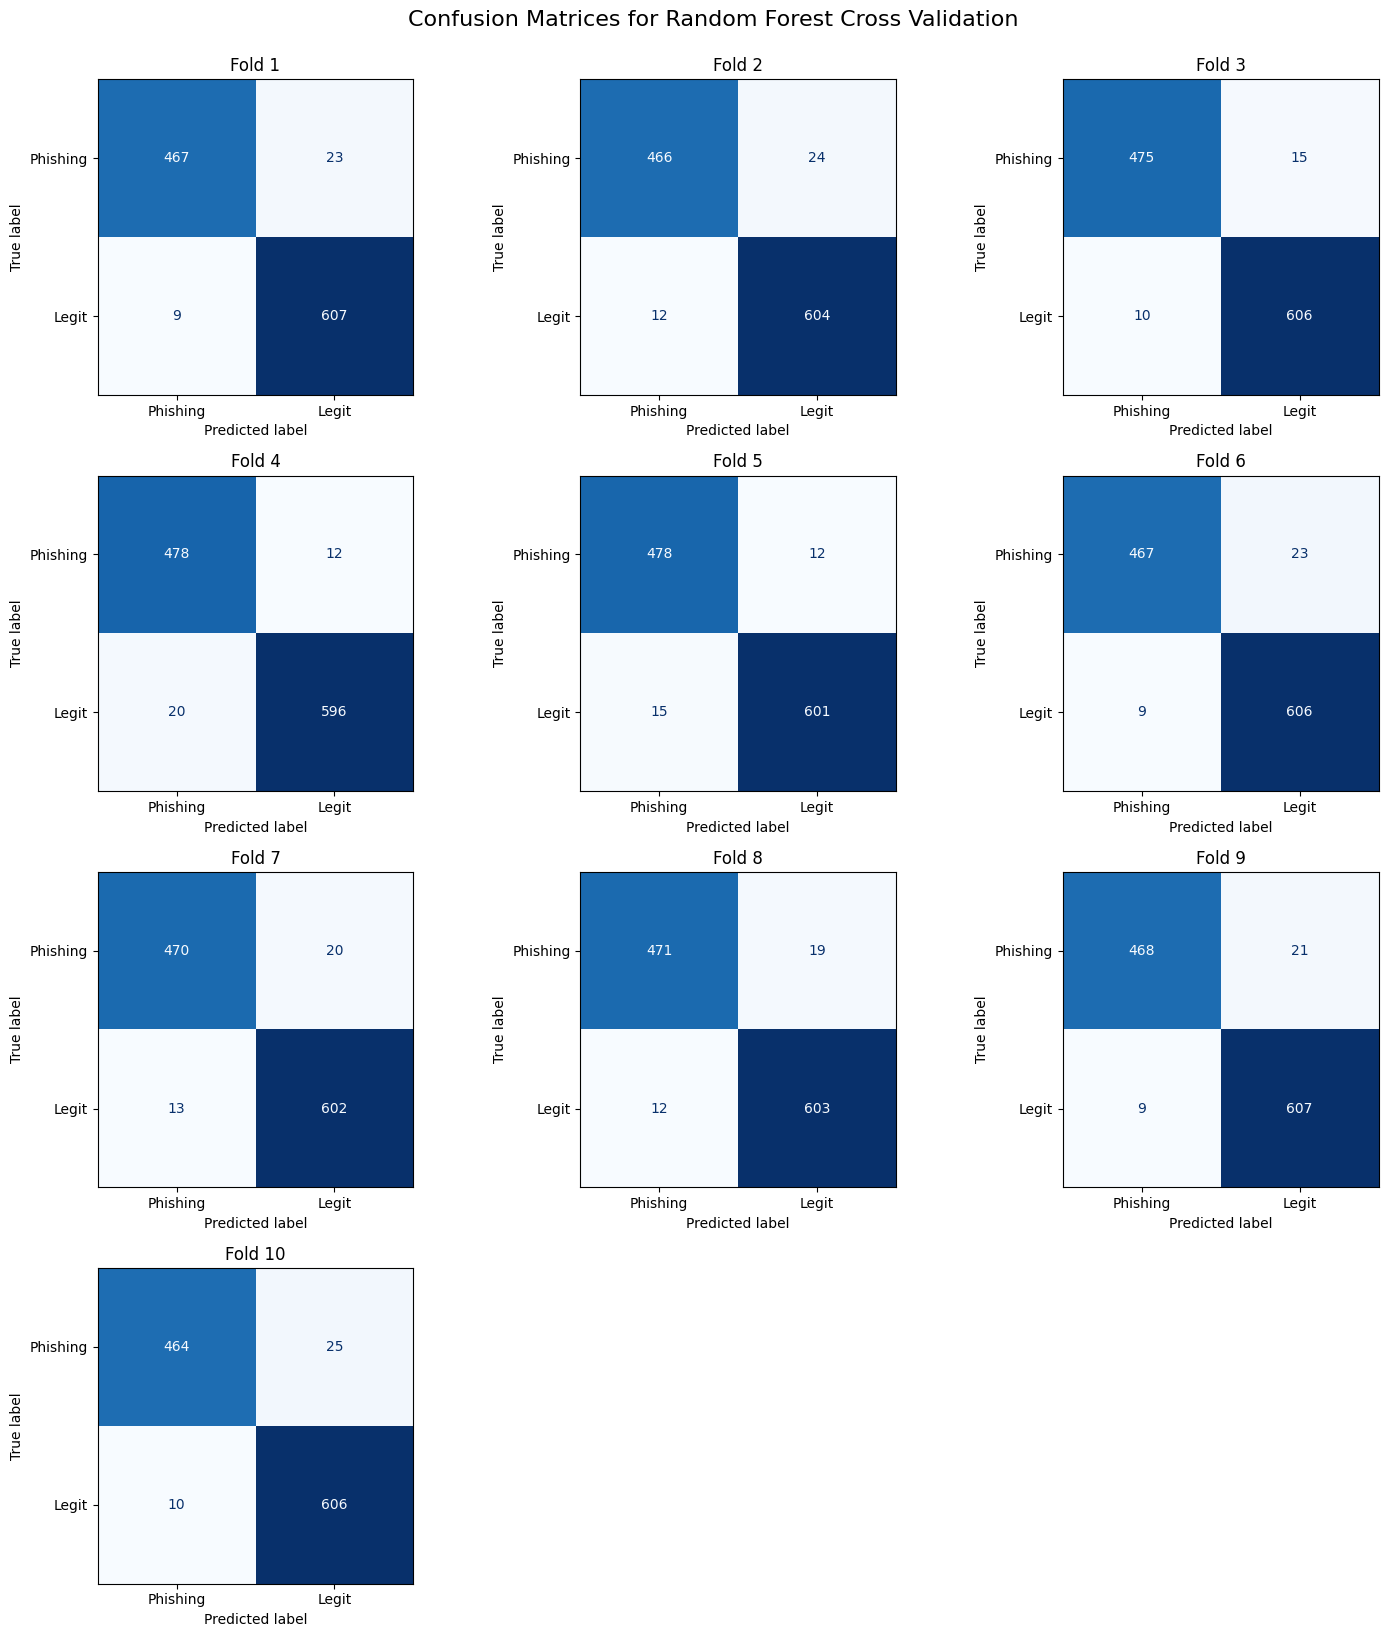

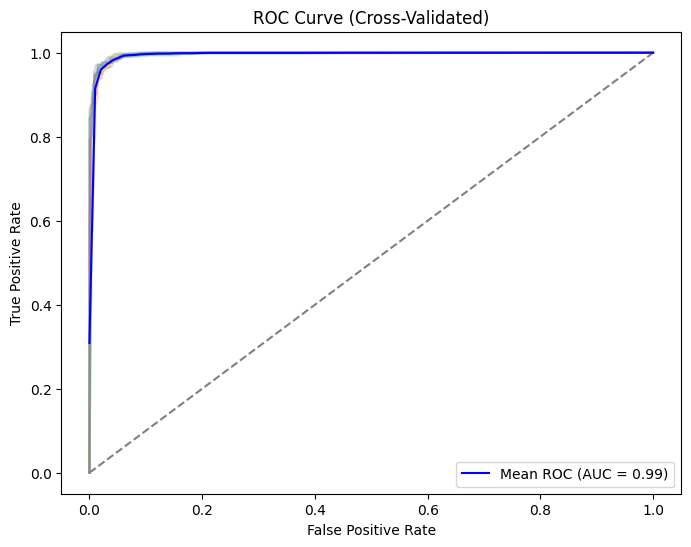


=== Random Forest Cross-Validated Metrics (Mean over Folds) ===
Average Accuracy:  0.9717

=== Average Per-Class Metrics (Cross-Validated) ===

Class -1 (Phishing):
  Avg Precision: 0.9754
  Avg Recall   : 0.9604
  Avg F1-score : 0.9678

Class 1 (Legit):
  Avg Precision: 0.9689
  Avg Recall   : 0.9807
  Avg F1-score : 0.9747



In [24]:
# --- (Gaussian + Cross Validation) with OneHot Encoding
accuracy_rf_list = []
precision_rf_list = []
recall_rf_list = []
f1_rf_list = []

# Manually collect per-class metrics during CV
from collections import defaultdict
class_metrics = defaultdict(list)

# Plot settings
n_folds = skf.get_n_splits()
cols = 3
rows = math.ceil(n_folds / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[val_idx]

    modelRF.fit(X_train_fold, y_train_fold)
    y_pred_rf_fold = modelRF.predict(X_test_fold)
    
   # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred_rf_fold)
    prec = precision_score(y_test_fold, y_pred_rf_fold)
    rec = recall_score(y_test_fold, y_pred_rf_fold)
    f1 = f1_score(y_test_fold, y_pred_rf_fold, average='macro')
    
    accuracy_rf_list.append(acc)
    precision_rf_list.append(prec)
    recall_rf_list.append(rec)
    f1_rf_list.append(f1)

    # Reporting the Fold
    report = classification_report(y_test_fold, y_pred_rf_fold, output_dict=True)
    for label in ['-1', '1']:  # string keys for labels
        for metric in ['precision', 'recall', 'f1-score']:
            class_metrics[(label, metric)].append(report[label][metric])

    # Plot confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred_rf_fold, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legit'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices for Random Forest Cross Validation", fontsize=16, y=1.02)
plt.show()

# ROC Curve
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8,6))

# Get index of class 1 in the columns of predict_proba
positive_class_index = list(modelRF.classes_).index(1)

for trainRoc, test in skf.split(X, y):
    modelRF.fit(X.iloc[trainRoc], y.iloc[trainRoc])
    probas_ = modelRF.predict_proba(X.iloc[test])
    fpr, tpr, thresholds = roc_curve(y.iloc[test], probas_[:, positive_class_index])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Cross-Validated)')
plt.legend()
plt.show()

# --- Print average metrics ---
print("\n=== Random Forest Cross-Validated Metrics (Mean over Folds) ===")
print(f"Average Accuracy:  {sum(accuracy_rf_list) / len(accuracy_rf_list):.4f}")
print()

print("=== Average Per-Class Metrics (Cross-Validated) ===")
for label in ['-1', '1']:
    print(f"\nClass {label} ({'Phishing' if label == '-1' else 'Legit'}):")
    for metric in ['precision', 'recall', 'f1-score']:
        values = class_metrics[(label, metric)]
        mean_val = sum(values) / len(values)
        print(f"  Avg {metric.capitalize():<9}: {mean_val:.4f}")
print()


The cross-validated metrics are slightly higher across all three categories. This suggests that the model performs consistently and even slightly better on average across folds than on the single held-out test set, which confirms our results and presents a good sign of stability.

### Results

The Random Forest Classifier shows a higher and more stable performance across folds compared to the Decision Tree metrics.

| **Model** | **Decision Tree** | **Random Forest** |
| --------- | ------------------ | ------------------ |
| Test Accuracy | 0.96              | **0.97**                     |
| Cross-Validated Accuracy| 0.9627          | **0.9717**                   |

| **Class -1: Phishing**    | **Decision Tree (CV)** | **Random Forest (CV)** |
| --------- | ------------------ | ------------------ |
| Precision | 0.9614             | **0.9754**         |
| Recall    | 0.9543             | **0.9604**         |
| F1-score  | 0.9578             | **0.9678**         |

| **Class 1: Legitimate**    | **Decision Tree (CV)** | **Random Forest (CV)** |
| --------- | ------------------ | ------------------ |
| Precision | 0.9639             | **0.9689**         |
| Recall    | 0.9695             | **0.9807**         |
| F1-score  | 0.9667             | **0.9747**         |

Therefore, Random Forest outperforms the Decision Tree across the board. Hence, **the Random Forest Classifier is our first candidate for the best classifier**. 


## Other Models (with OneHotEncoding)

### OneHot Encoding

We use **One-hot encoding** to convert categorical data into a format that can be provided to machine learning algorithms to improve prediction performance. This is done due to the necessity of the next two classifiers that have the strict necessity to work with numerical inputs.

Next up we show how our dataset looks like after the OneHot encoding procedure.

To train the models we will instead use a **pipeline**, to prevent data leakage. 

In [25]:
# One-hot encode the features
encoderOH = OneHotEncoder(sparse_output=False)
X_encodedOH = encoderOH.fit_transform(X)
X_encodedOH_df = pd.DataFrame(X_encodedOH, columns=encoderOH.get_feature_names_out(X.columns))

X_encodedOH_df.head(10)

,having_IP_Address_-1,having_IP_Address_1,URL_Length_-1,URL_Length_0,URL_Length_1,Shortining_Service_-1,Shortining_Service_1,having_At_Symbol_-1,having_At_Symbol_1,double_slash_redirecting_-1,...,web_traffic_1,Page_Rank_-1,Page_Rank_1,Google_Index_-1,Google_Index_1,Links_pointing_to_page_-1,Links_pointing_to_page_0,Links_pointing_to_page_1,Statistical_report_-1,Statistical_report_1
0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
5,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
7,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
8,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
9,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


### Naïve Bayesian Classifier

#### Pipeline (Naïve Bayesian + OneHot Encoding)

In [26]:
# --- Naive Bayes
nb_pipeline = make_pipeline(
    OneHotEncoder(sparse_output=False),
    CategoricalNB()
)

# Fit and evaluate Naive Bayes
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)
y_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]
print("=== Naïve Bayes Report ===")
print(classification_report(y_test, y_pred_nb))

# save the model for live analysis
joblib.dump(nb_pipeline, "models/phishing_model_nb.pkl");

=== Naïve Bayes Report ===
              precision    recall  f1-score   support

          -1       0.92      0.91      0.92       956
           1       0.93      0.94      0.94      1255

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



#### Plotting

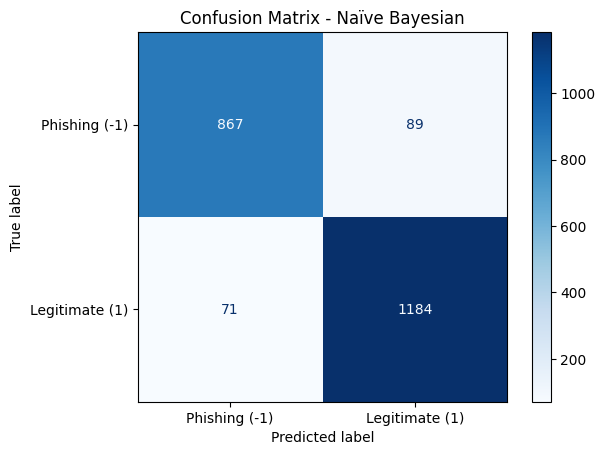

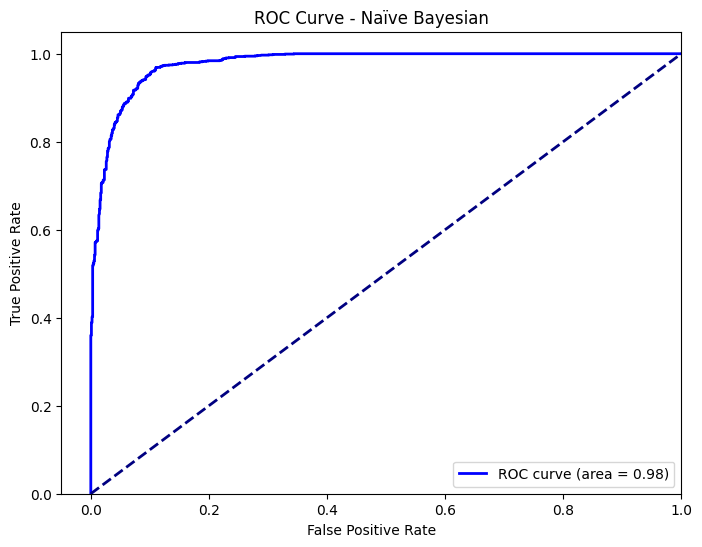

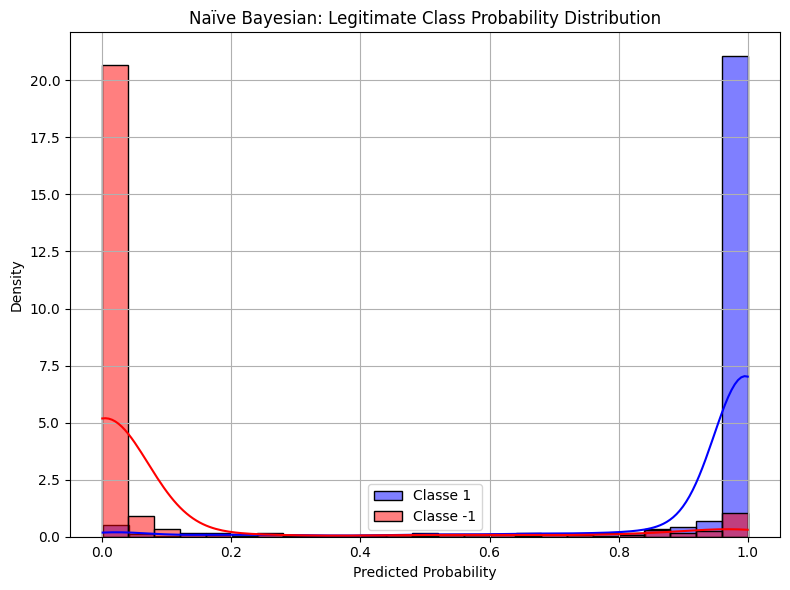

In [27]:
# Confusion Matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb, labels=[-1, 1])
disp_nb = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_nb, display_labels=["Phishing (-1)", "Legitimate (1)"])

disp_nb.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Naïve Bayesian")
plt.grid(False)
plt.show()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_nb)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naïve Bayesian')
plt.legend(loc="lower right")
plt.show()

# Distribuzione delle probabilità predette
y_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]  # probabilità classe 1

plt.figure(figsize=(8, 6))
sns.histplot(y_proba_nb[y_test == 1], bins=25, color='blue', label='Classe 1', stat='density', kde=True)
sns.histplot(y_proba_nb[y_test == -1], bins=25, color='red', label='Classe -1', stat='density', kde=True)
plt.title('Naïve Bayesian: Legitimate Class Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Naïve Bayesian classifier shows a step back from the two previous models performance, achieving an F1-score of (0.92, 0.94) for the phishing and legitimate classes respectively, and a test accuracy of (0.93). The confusion matrix indicates that the model makes a fair number of errors, with 89 false positives and 71 false negatives, slightly higher than the Decision Tree and Random Forest.

The ROC Curve shows an AUC of 0.98, which is surprisingly strong and suggests that the model is quite effective in ranking predictions by confidence. The probability distribution plot confirms this, showing high-confidence predictions on both ends, but with a bit more overlap in the mid-range compared to tree-based models, implying occasional confusion around borderline cases.

Overall, Naïve Bayesian offers competitive performance with excellent computational efficiency, though it is slightly less precise and reliable than Random Forest or Decision Tree in this context.

We proceed with the cross-validation of the model to confirm these results.

#### Naive Bayesian Cross Validated

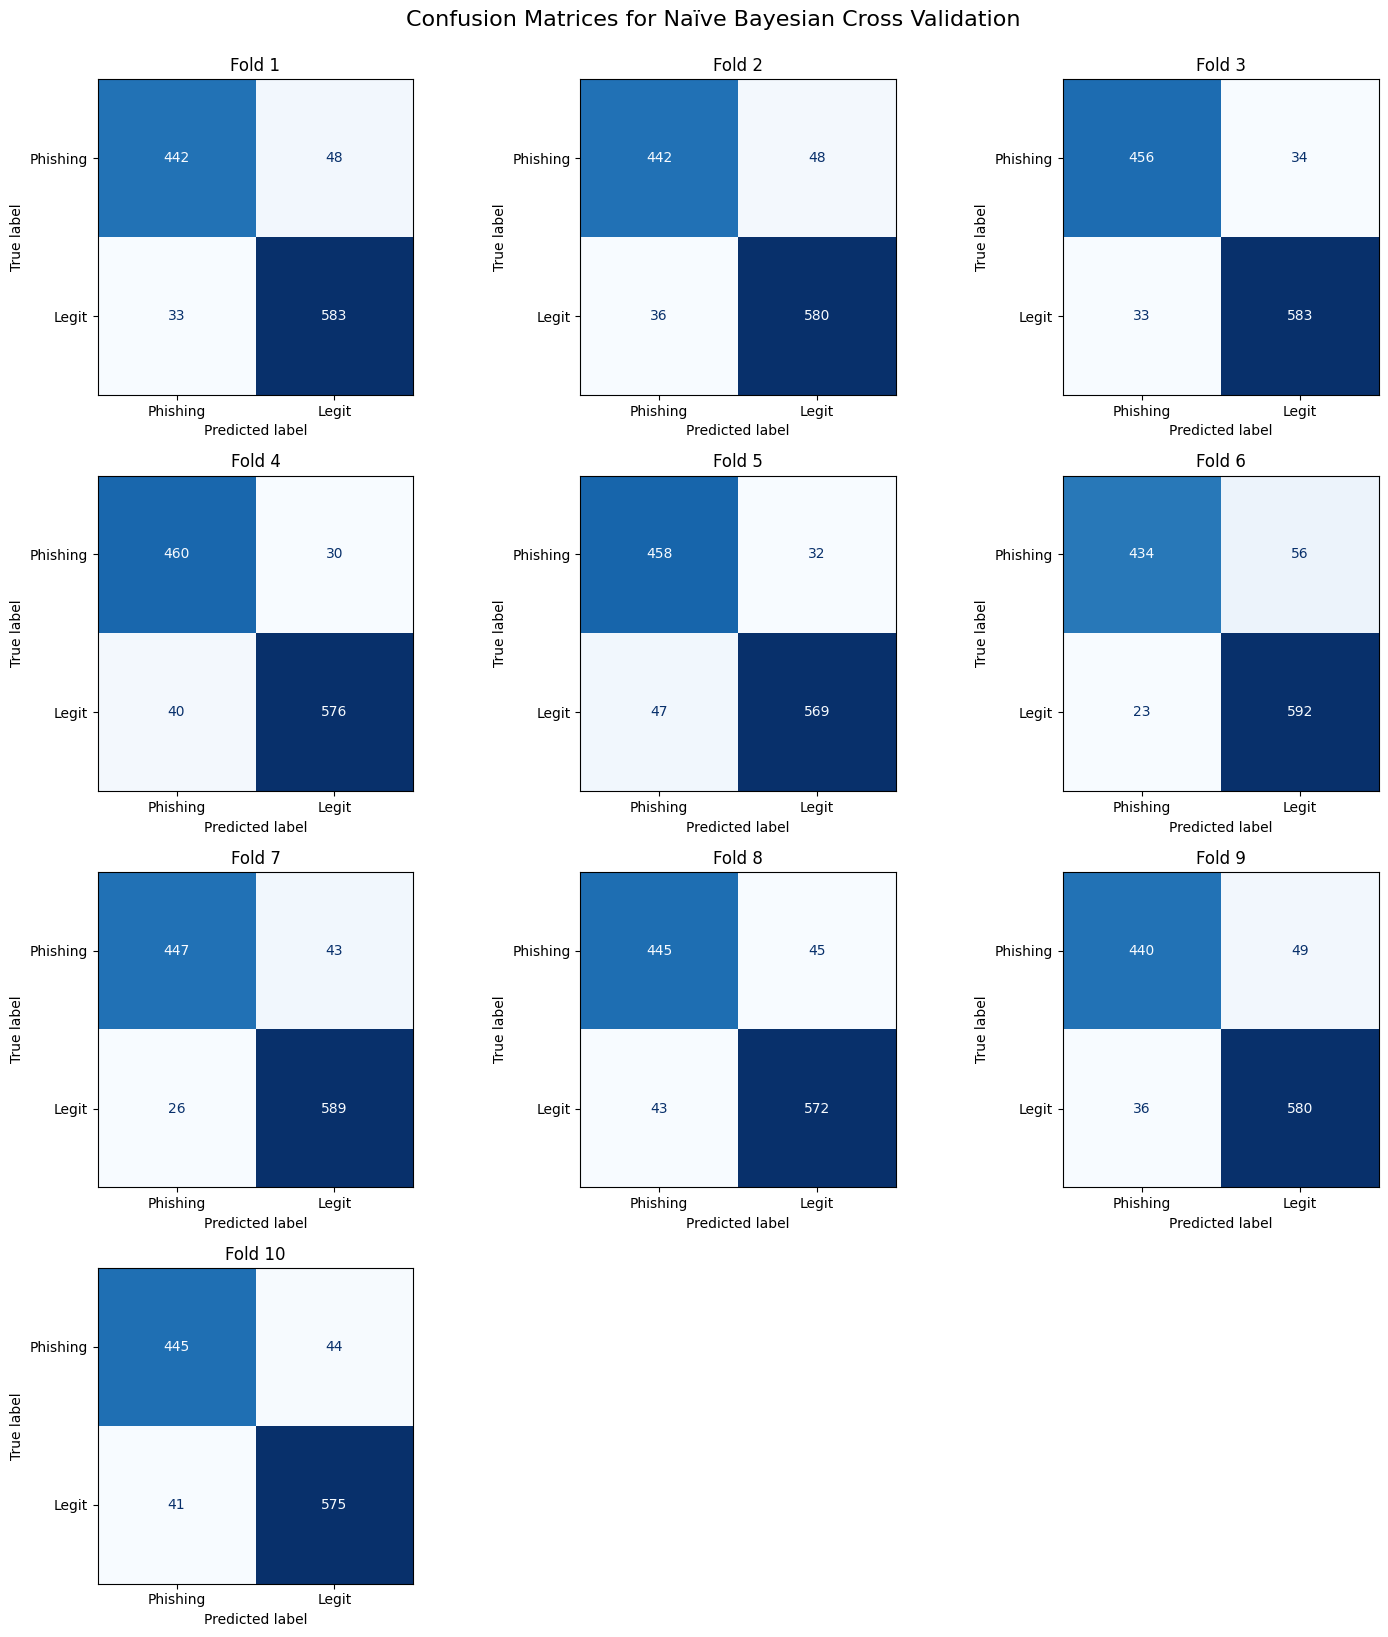

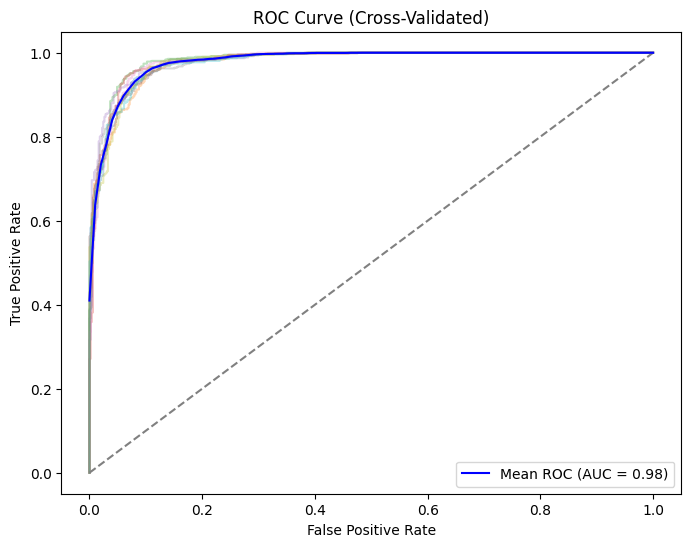


=== Naive Bayesian Cross-Validated Metrics (Mean over Folds) ===
Average Accuracy:  0.9288

=== Average Per-Class Metrics (Cross-Validated) ===

Class -1 (Phishing):
  Avg Precision: 0.9261
  Avg Recall   : 0.9124
  Avg F1-score : 0.9190

Class 1 (Legit):
  Avg Precision: 0.9313
  Avg Recall   : 0.9419
  Avg F1-score : 0.9365



In [28]:
# --- (Gaussian + Cross Validation) with OneHot Encoding
accuracy_nb_list = []
precision_nb_list = []
recall_nb_list = []
f1_nb_list = []

# Manually collect per-class metrics during CV
from collections import defaultdict
class_metrics = defaultdict(list)

# Plot settings
n_folds = skf.get_n_splits()
cols = 3
rows = math.ceil(n_folds / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[val_idx]

    nb_pipeline.fit(X_train_fold, y_train_fold)
    y_pred_nb_fold = nb_pipeline.predict(X_test_fold)
    
   # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred_nb_fold)
    prec = precision_score(y_test_fold, y_pred_nb_fold)
    rec = recall_score(y_test_fold, y_pred_nb_fold)
    f1 = f1_score(y_test_fold, y_pred_nb_fold, average='macro')
    
    accuracy_nb_list.append(acc)
    precision_nb_list.append(prec)
    recall_nb_list.append(rec)
    f1_nb_list.append(f1)

    # Reporting the Fold
    report = classification_report(y_test_fold, y_pred_nb_fold, output_dict=True)
    for label in ['-1', '1']:  # string keys for labels
        for metric in ['precision', 'recall', 'f1-score']:
            class_metrics[(label, metric)].append(report[label][metric])

    # Plot confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred_nb_fold, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legit'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices for Naïve Bayesian Cross Validation", fontsize=16, y=1.02)
plt.show()

# ROC Curve
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8,6))

# Get index of class 1 in the columns of predict_proba
positive_class_index = list(nb_pipeline.classes_).index(1)

for trainRoc, test in skf.split(X, y):
    nb_pipeline.fit(X.iloc[trainRoc], y.iloc[trainRoc])
    probas_ = nb_pipeline.predict_proba(X.iloc[test])
    fpr, tpr, thresholds = roc_curve(y.iloc[test], probas_[:, positive_class_index])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Cross-Validated)')
plt.legend()
plt.show()

# --- Print average metrics ---
print("\n=== Naive Bayesian Cross-Validated Metrics (Mean over Folds) ===")
print(f"Average Accuracy:  {sum(accuracy_nb_list) / len(accuracy_nb_list):.4f}")
print()

print("=== Average Per-Class Metrics (Cross-Validated) ===")
for label in ['-1', '1']:
    print(f"\nClass {label} ({'Phishing' if label == '-1' else 'Legit'}):")
    for metric in ['precision', 'recall', 'f1-score']:
        values = class_metrics[(label, metric)]
        mean_val = sum(values) / len(values)
        print(f"  Avg {metric.capitalize():<9}: {mean_val:.4f}")
print()


The cross-validated accuracy is slightly lower than the Naive Bayesian single test, but still presents consistent results.

| **CNB Metrics**   | **Test Accuracy** | **Cross-Validated Accuracy** |
| ------------ | ----------------- | ---------------------------- |
| **Accuracy** | 0.93              | 0.9288                       |

| **Class -1**    | **Test F1-score** | **Cross-Validated F1-score** |
| ------------- | ----------------- | ---------------------------- |
| **Precision** | 0.92              | 0.9261                       |
| **Recall**    | 0.91              | 0.9124                       |
| **F1-score**  | 0.92              | 0.9190                       |

| **Calss 1**    | **Test F1-score** | **Cross-Validated F1-score** |
| ------------- | ----------------- | ---------------------------- |
| **Precision** | 0.93              | 0.9313                       |
| **Recall**    | 0.94              | 0.9419                       |
| **F1-score**  | 0.94              | 0.9365                       |




### Logistic Regression

#### Pipeline (Logistic Regression + OneHot Encoding)

In [29]:
lr_pipeline = make_pipeline(
    OneHotEncoder(sparse_output=False),
    LogisticRegression()
)

# Fit and evaluate Logistic Regression
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
print("=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))

# save the model for live analysis
joblib.dump(lr_pipeline, "models/phishing_model_lr.pkl");

=== Logistic Regression Report ===
              precision    recall  f1-score   support

          -1       0.94      0.92      0.93       956
           1       0.94      0.95      0.95      1255

    accuracy                           0.94      2211
   macro avg       0.94      0.94      0.94      2211
weighted avg       0.94      0.94      0.94      2211



#### Plotting

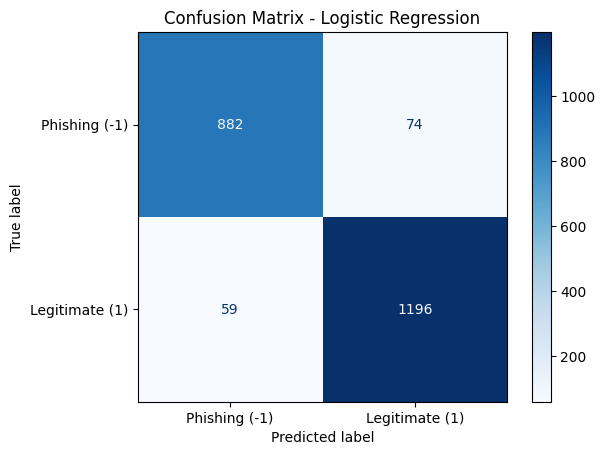

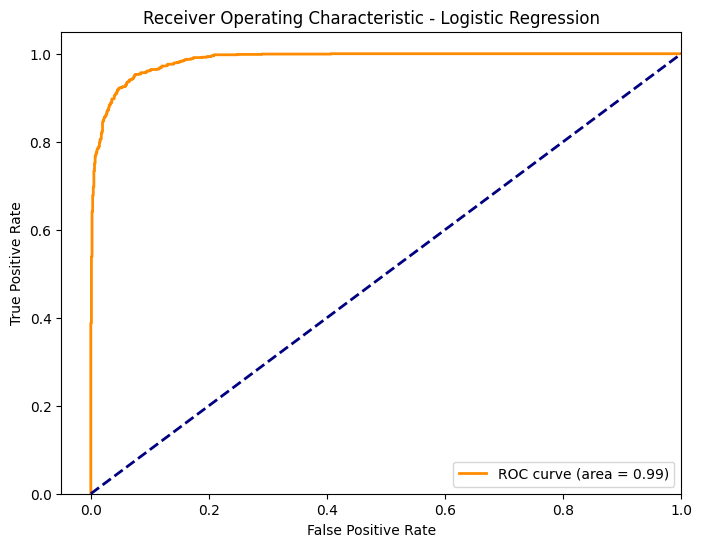

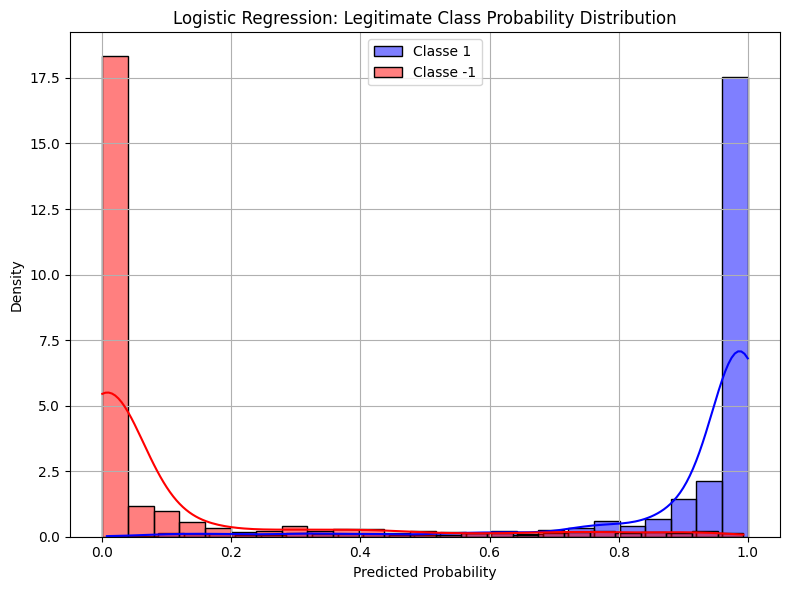

In [30]:
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr, labels=[-1, 1])

disp_lr = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_lr, display_labels=["Phishing (-1)", "Legitimate (1)"])

disp_lr.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# Distribuzione delle probabilità predette
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]  # probabilità classe 1

plt.figure(figsize=(8, 6))
sns.histplot(y_proba_lr[y_test == 1], bins=25, color='blue', label='Classe 1', stat='density', kde=True)
sns.histplot(y_proba_lr[y_test == -1], bins=25, color='red', label='Classe -1', stat='density', kde=True)
plt.title('Logistic Regression: Legitimate Class Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The Logistic Regression model demonstrates strong performance, achieving an F1-score of (0.93) for the phishing class and (0.95) for the legitimate class, with an overall test accuracy of (0.94). The confusion matrix shows relatively low error rates, with 74 false positives and 59 false negatives, suggesting that the model handles both phishing and legitimate URLs with high precision and recall.

The ROC Curve ha an AUC of (0.99), indicating excellent discriminative ability in separating the two classes, meaning the model is highly effective at ranking instances by confidence.

The class probability distribution plot shows strong confidence in its predictions, with clear separation between classes—most predictions are close to either 0 or 1. There’s minimal overlap in the mid-range, implying the model rarely struggles with ambiguous cases.

Overall, Logistic Regression proves to be a robust and interpretable model in our context for detection of Phishing URLs.

We proceed with the cross-validation of the model to confirm these results.

#### Logistic Regression Cross Validated

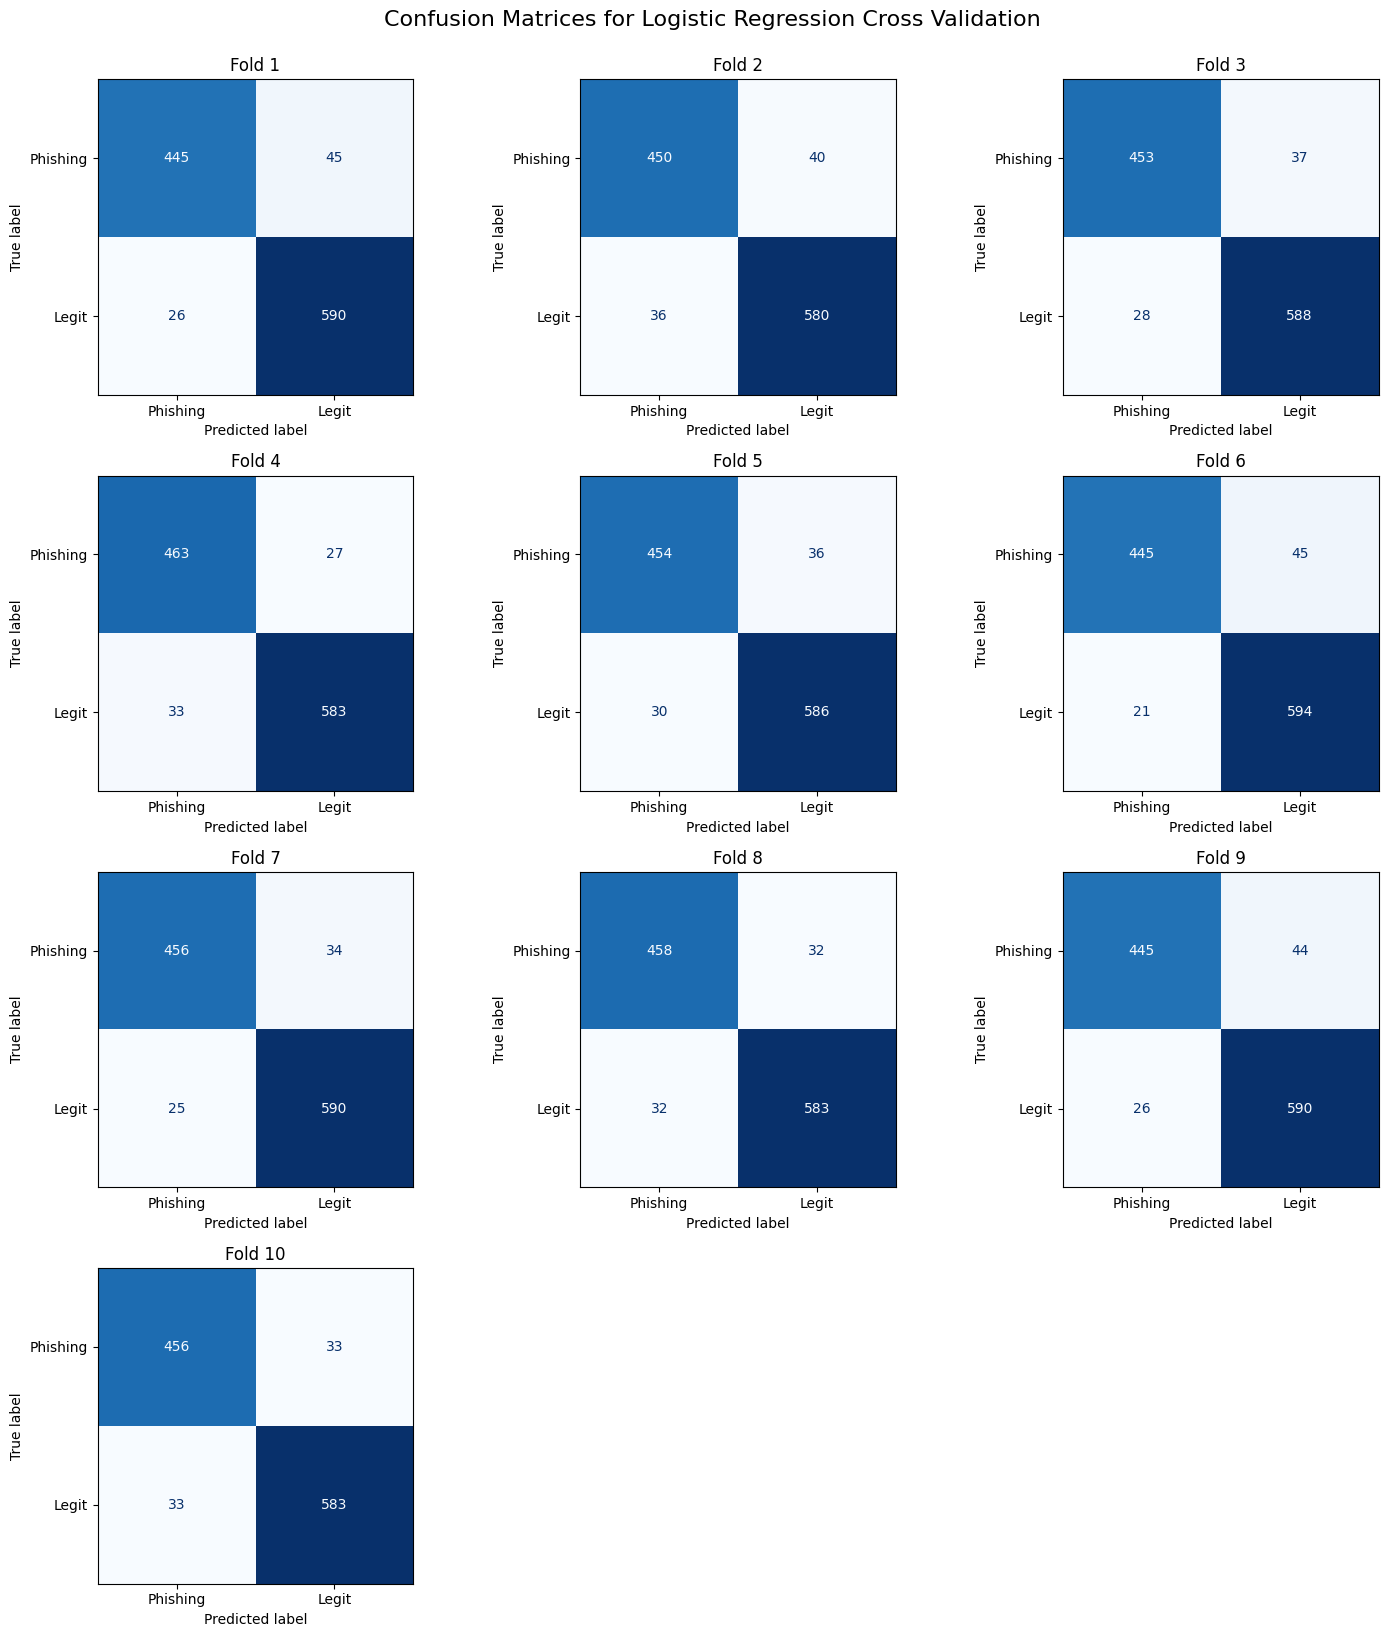

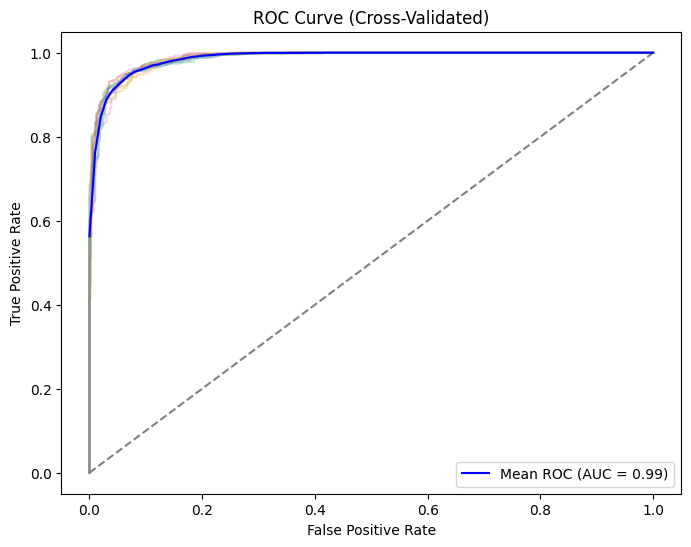


=== Logistic Regression Cross-Validated Metrics (Mean over Folds) ===
Average Accuracy:  0.9400

=== Average Per-Class Metrics (Cross-Validated) ===

Class -1 (Phishing):
  Avg Precision: 0.9399
  Avg Recall   : 0.9238
  Avg F1-score : 0.9317

Class 1 (Legit):
  Avg Precision: 0.9403
  Avg Recall   : 0.9529
  Avg F1-score : 0.9465



In [31]:
# --- (LR + Cross Validation) with OneHot Encoding
accuracy_lr_list = []
precision_lr_list = []
recall_lr_list = []
f1_lr_list = []

# Manually collect per-class metrics during CV
from collections import defaultdict
class_metrics = defaultdict(list)

# Plot settings
n_folds = skf.get_n_splits()
cols = 3
rows = math.ceil(n_folds / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[val_idx]

    lr_pipeline.fit(X_train_fold, y_train_fold)
    y_pred_lr_fold = lr_pipeline.predict(X_test_fold)
    
   # Compute metrics
    acc = accuracy_score(y_test_fold, y_pred_lr_fold)
    prec = precision_score(y_test_fold, y_pred_lr_fold)
    rec = recall_score(y_test_fold, y_pred_lr_fold)
    f1 = f1_score(y_test_fold, y_pred_lr_fold, average='macro')
    
    accuracy_lr_list.append(acc)
    precision_lr_list.append(prec)
    recall_lr_list.append(rec)
    f1_lr_list.append(f1)

    # Reporting the Fold
    report = classification_report(y_test_fold, y_pred_lr_fold, output_dict=True)
    for label in ['-1', '1']:  # string keys for labels
        for metric in ['precision', 'recall', 'f1-score']:
            class_metrics[(label, metric)].append(report[label][metric])

    # Plot confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred_lr_fold, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legit'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Fold {i+1}")

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices for Logistic Regression Cross Validation", fontsize=16, y=1.02)
plt.show()

# ROC Curve
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8,6))

# Get index of class 1 in the columns of predict_proba
positive_class_index = list(lr_pipeline.classes_).index(1)

for trainRoc, test in skf.split(X, y):
    lr_pipeline.fit(X.iloc[trainRoc], y.iloc[trainRoc])
    probas_ = lr_pipeline.predict_proba(X.iloc[test])
    fpr, tpr, thresholds = roc_curve(y.iloc[test], probas_[:, positive_class_index])
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Cross-Validated)')
plt.legend()
plt.show()

# --- Print average metrics ---
print("\n=== Logistic Regression Cross-Validated Metrics (Mean over Folds) ===")
print(f"Average Accuracy:  {sum(accuracy_lr_list) / len(accuracy_lr_list):.4f}")
print()

print("=== Average Per-Class Metrics (Cross-Validated) ===")
for label in ['-1', '1']:
    print(f"\nClass {label} ({'Phishing' if label == '-1' else 'Legit'}):")
    for metric in ['precision', 'recall', 'f1-score']:
        values = class_metrics[(label, metric)]
        mean_val = sum(values) / len(values)
        print(f"  Avg {metric.capitalize():<9}: {mean_val:.4f}")
print()


The cross-validated accuracy matches the single test evaluation, demonstrating consistent and reliable performance across different data splits.

| **Logistic Regression Metrics** | **Test Accuracy** | **Cross-Validated Accuracy** |
| ------------------------------- | ----------------- | ---------------------------- |
| **Accuracy**                    | 0.94              | 0.9400                       |

| **Class -1 (Phishing)** | **Test F1-score** | **Cross-Validated F1-score** |
| ----------------------- | ----------------- | ---------------------------- |
| **Precision**           | 0.94              | 0.9399                       |
| **Recall**              | 0.92              | 0.9238                       |
| **F1-score**            | 0.93              | 0.9317                       |

| **Class 1 (Legitimate)** | **Test F1-score** | **Cross-Validated F1-score** |
| ------------------------ | ----------------- | ---------------------------- |
| **Precision**            | 0.94              | 0.9403                       |
| **Recall**               | 0.95              | 0.9529                       |
| **F1-score**             | 0.95              | 0.9465                       |

### Results

The Logistic Regression model outperforms the Naive Bayesian classifier in nearly all metrics, offering more consistent and slightly higher performance across both the test set and cross-validation.

| **Model**                | **Naive Bayes (CNB)** | **Logistic Regression** |
| ------------------------ | --------------------- | ----------------------- |
| Test Accuracy            | 0.93                  | **0.94**                |
| Cross-Validated Accuracy | 0.9288                | **0.9400**              |

| **Class -1: Phishing** | **Naive Bayes (CV)** | **Logistic Regression (CV)** |
| ---------------------- | -------------------- | ---------------------------- |
| Precision              | 0.9261               | **0.9399**                   |
| Recall                 | 0.9124               | **0.9238**                   |
| F1-score               | 0.9190               | **0.9317**                   |

| **Class 1: Legitimate** | **Naive Bayes (CV)** | **Logistic Regression (CV)** |
| ----------------------- | -------------------- | ---------------------------- |
| Precision               | 0.9313               | **0.9403**                   |
| Recall                  | 0.9419               | **0.9529**                   |
| F1-score                | 0.9365               | **0.9465**                   |


Therefore, Logistic Regression outperforms the Naive Bayesian. Hence, **the Logistic Regression Classifier is our second candidate for the best classifier**. 



# Evaluation of the Best Classifier

To determine the best classifier, we made two decisions beforehand, we chose:

- The best Decision Tree Family Classifier: **Random Forest Classifier**
- The best of the others: **Logistic Regression Classifier**

We proceed to confront the distribution of their F1-scores and Accuracies, to then proceed with the T-Testing to determine the best classifier out of the two.

## Distributions of the F1-Scores and Accuracy

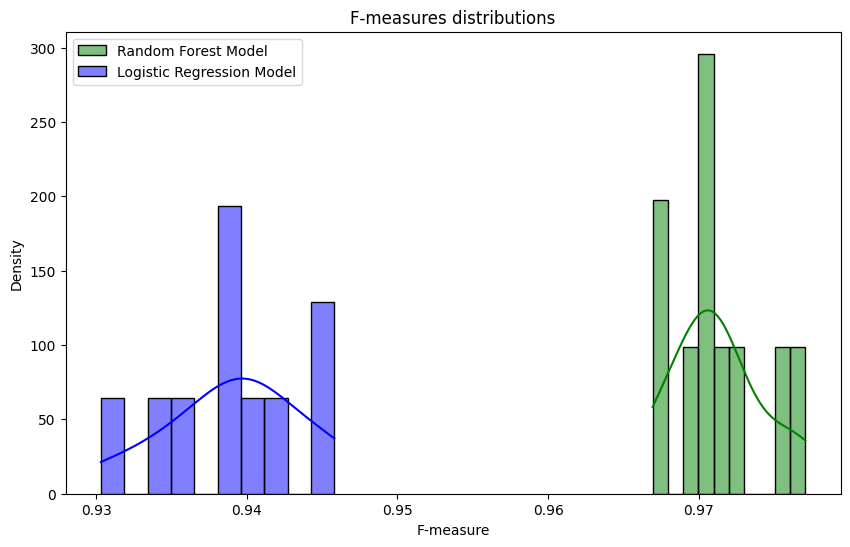

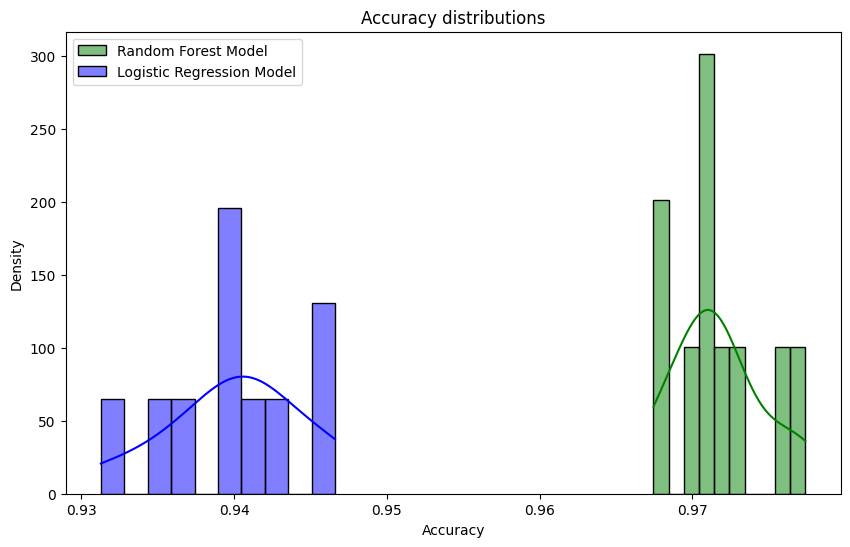

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(f1_rf_list, kde=True, color="green", label="Random Forest Model", stat="density", bins=10)
sns.histplot(f1_lr_list, kde=True, color="blue", label="Logistic Regression Model", stat="density", bins=10)

plt.title('F-measures distributions')
plt.xlabel('F-measure')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(accuracy_rf_list, kde=True, color="green", label="Random Forest Model", stat="density", bins=10)
sns.histplot(accuracy_lr_list, kde=True, color="blue", label="Logistic Regression Model", stat="density", bins=10)

plt.title('Accuracy distributions')
plt.xlabel('Accuracy')
plt.ylabel('Density')
plt.legend()
plt.show()

The plots show clear differences in performance distributions between the Random Forest and Logistic Regression models. 

The Random Forest has both the F-measure and accuracy distributions around high values (≈0.97), indicating not only better overall performance but also greater stability across cross-validation folds. 

In contrast, the Logistic Regression model shows more spread and lower values (≈0.94), suggesting slightly less precision and consistency.

## T-Testing

We proceed to implement the t-testing approach such that we are able to compare the means of the two chosen classifiers and determine if the difference is statistically significant, or not.

In [33]:
from scipy.stats import ttest_rel

# Paired t-test on F1 scores from Random Forest and Logistic Regression
t_stat_f1, p_value_f1 = ttest_rel(f1_rf_list, f1_lr_list)
df_f1 = len(f1_rf_list) - 1  # degrees of freedom (n - 1)

print("T-Testing - Degrees of Freedom (9)\n")
print(f"Paired t-test on F1 Scores:")
print(f"t-statistic({df_f1}) = {t_stat_f1:.4f}, p = {p_value_f1:.10f}")
print("-> Direct comparison between the F1 scores of Random Forest vs Logistic Regression.\n")

# Paired t-test on Accuracy scores
t_stat_acc, p_value_acc = ttest_rel(accuracy_rf_list, accuracy_lr_list)
df_acc = len(accuracy_rf_list) - 1  # degrees of freedom

print(f"Paired t-test on Accuracy Scores:")
print(f"t-statistic({df_acc}) = {t_stat_acc:.4f}, p = {p_value_acc:.10f}")
print("-> Direct comparison between the Accuracy scores of Random Forest vs Logistic Regression.\n")


T-Testing - Degrees of Freedom (9)

Paired t-test on F1 Scores:
t-statistic(9) = 20.5339, p = 0.0000000072
-> Direct comparison between the F1 scores of Random Forest vs Logistic Regression.

Paired t-test on Accuracy Scores:
t-statistic(9) = 20.6993, p = 0.0000000067
-> Direct comparison between the Accuracy scores of Random Forest vs Logistic Regression.



The results of the paired t-tests provide strong statistical evidence that the **Random Forest model significantly outperforms the Logistic Regression model in both F1 score and accuracy**. 

With a t-statistic of over 20 in both tests and extremely low p-values, the probability that these differences occurred by chance is virtually zero. 

These results confirm that the performance gaps observed in the distribution plots are statistically significant, further solidifying and confirming **the Random Forest as the superior model in this comparison**.

Therefore, we proceed to save the Random Forest model to be used in the Live URL Analyzer.

In [34]:
# Live Analysis uses the best model available
best_model_path = "models/phishing_model_rf.pkl"

# Live URL Analyzer

## Feature Extraction

This section of code aims to implement a function that, once a URL has been provided to it, is able to analyse it and construct a dictionary containing the 29 features that are necessary for the Random Forest model to perform a prediction on it. 

In [35]:
def extract_features_from_url(url: str) -> dict:
    
    if not url.startswith("http"):
        url = "http://" + url  # Forza parsing corretto

    parsed = urlparse(url)
    hostname = parsed.netloc

    scheme = parsed.scheme
    path = parsed.path
    features = {}

    def get_domain_age(domain):
        try:
            domain_info = whois.whois(domain)
            creation_date = domain_info.creation_date
            if isinstance(creation_date, list):
                creation_date = creation_date[0]
            age_in_months = (datetime.now() - creation_date).days // 30
            return age_in_months
        except:
            return -1

    def get_registration_length(domain):
        try:
            domain_info = whois.whois(domain)
            expiration_date = domain_info.expiration_date
            creation_date = domain_info.creation_date
            if isinstance(expiration_date, list):
                expiration_date = expiration_date[0]
            if isinstance(creation_date, list):
                creation_date = creation_date[0]
            length = (expiration_date - creation_date).days // 365
            return length
        except:
            return -1

    # 1-8 Basic Address Bar Features
    features['having_IP_Address'] = -1 if re.match(r"^\d{1,3}(\.\d{1,3}){3}", hostname) else 1
    features['URL_Length'] = 1 if len(url) < 54 else (0 if len(url) <= 75 else -1)
    features['Shortining_Service'] = -1 if re.search(r"(bit\.ly|goo\.gl|tinyurl|ow\.ly|t\.co)", url) else 1
    features['having_At_Symbol'] = -1 if "@" in url else 1
    features['double_slash_redirecting'] = -1 if url.count('//') > 1 else 1
    features['Prefix_Suffix'] = -1 if '-' in hostname else 1
    dot_count = hostname.replace('www.', '').count('.')
    features['having_Sub_Domain'] = 1 if dot_count <= 1 else (0 if dot_count == 2 else -1)
    features['SSLfinal_State'] = 1 if scheme == 'https' else -1

    # 9. Domain_registeration_length
    length = get_registration_length(hostname)
    features['Domain_registeration_length'] = 1 if length > 1 else -1

    # 10. Favicon - simulate by checking if icon is from same domain
    try:
        response = requests.get(url, timeout=5)
        icon_links = re.findall(r'rel=["\']icon["\'][^>]*href=["\'](.*?)["\']', response.text, re.IGNORECASE)
        features['Favicon'] = 1 if all(hostname in icon for icon in icon_links) else -1
    except:
        features['Favicon'] = -1

    # 11. port
    try:
        port = parsed.port if parsed.port else (443 if scheme == "https" else 80)
        features['port'] = 1 if port in [80, 443] else -1
    except:
        features['port'] = -1

    # 12. HTTPS_token
    features['HTTPS_token'] = -1 if 'https' in hostname.lower() else 1

    # 13. Request_URL (external media domain)
    '''
    try:
        objects = re.findall(r'src=["\'](.*?)["\']', response.text)
        ext_count = sum(1 for obj in objects if hostname not in obj)
        features['Request_URL'] = 1 if ext_count < len(objects) / 2 else -1
    except:
        features['Request_URL'] = -1
    '''
    try:
        objects = re.findall(r'src=["\'](.*?)["\']', response.text)
        if not objects:
            features['Request_URL'] = 0  # No media objects to evaluate
        else:
            ext_count = sum(1 for obj in objects if hostname not in obj)
            ratio = ext_count / len(objects)
            features['Request_URL'] = 1 if ratio < 0.5 else -1
    except:
        features['Request_URL'] = 0  # Ambiguous case

    # 14. URL_of_Anchor
    try:
        anchors = re.findall(r'<a\s+(?:[^>]*?\s+)?href=["\'](.*?)["\']', response.text)
        null_or_external = sum(1 for a in anchors if a.startswith('#') or 'javascript' in a.lower() or hostname not in a)
        features['URL_of_Anchor'] = 1 if null_or_external < len(anchors) / 2 else -1
    except:
        features['URL_of_Anchor'] = -1

    # 15. Links_in_tags
    '''
    try:
        tags = re.findall(r'<(meta|script|link)[^>]+href=["\'](.*?)["\']', response.text)
        ext_count = sum(1 for tag, link in tags if hostname not in link)
        features['Links_in_tags'] = 1 if ext_count < len(tags) / 2 else -1
    except:
        features['Links_in_tags'] = -1
    '''
    try:
        tags = re.findall(r'<(meta|script|link)[^>]+(?:href|src)=["\'](.*?)["\']', response.text, re.IGNORECASE)
        total = len(tags)
        ext_count = sum(1 for tag, link in tags if hostname not in link)
    
        if total == 0:
            features['Links_in_tags'] = 1  # If no tags found, assume safe
        else:
            ext_ratio = (ext_count / total) * 100
            if ext_ratio < 17:
                features['Links_in_tags'] = 1  # Legitimate
            elif 17 <= ext_ratio <= 81:
                features['Links_in_tags'] = 0  # Suspicious
            else:
                features['Links_in_tags'] = -1  # Phishing
    except:
        features['Links_in_tags'] = -1  # Treat parse failure as phishing (conservative)

    # 16. SFH
    try:
        forms = re.findall(r'<form[^>]*action=["\'](.*?)["\']', response.text, re.IGNORECASE)
        sfh_flag = 1
        for action in forms:
            if action == "" or "about:blank" in action or hostname not in action:
                sfh_flag = -1
                break
        features['SFH'] = sfh_flag
    except:
        features['SFH'] = -1

    # 17. Submitting_to_email
    features['Submitting_to_email'] = -1 if "mailto:" in url else 1

    # 18. Abnormal_URL
    try:
        domain_info = whois.whois(hostname)
        features['Abnormal_URL'] = 1 if domain_info.domain_name else -1
    except:
        features['Abnormal_URL'] = -1

    # 19. Redirect - count of meta/JS redirects
    try:
        redir_count = len(re.findall(r'http-equiv=["\']refresh["\']', response.text, re.IGNORECASE))
        features['Redirect'] = -1 if redir_count >= 4 else (0 if redir_count > 1 else 1)
    except:
        features['Redirect'] = -1

    # 20. on_mouseover
    try:
        features['on_mouseover'] = -1 if re.search(r'onmouseover\s*=\s*["\'].*status', response.text, re.IGNORECASE) else 1
    except:
        features['on_mouseover'] = -1

    # 21. RightClick
    try:
        features['RightClick'] = -1 if re.search(r'event.button ?== ?2', response.text) else 1
    except:
        features['RightClick'] = -1
    '''
    # 22. popUpWidnow
    try:
        features['popUpWindow'] = -1 if re.search(r'alert\(|window\.open\(', response.text, re.IGNORECASE) else 1
    except:
        features['popUpWindow'] = -1
    '''
    # 23. Iframe
    try:
        features['Iframe'] = -1 if re.search(r'<iframe[^>]*frameborder=["\']?0', response.text, re.IGNORECASE) else 1
    except:
        features['Iframe'] = -1

    # 24. age_of_domain
    age = get_domain_age(hostname)
    features['age_of_domain'] = 1 if age >= 6 else -1

    # 25. DNSRecord
    try:
        socket.gethostbyname(hostname)
        features['DNSRecord'] = 1
    except:
        features['DNSRecord'] = -1

    # 26. web_traffic – Placeholder unless Alexa API or similar is integrated
    #features['web_traffic'] = 1  # Needs actual Alexa or traffic source
    def get_tranco_rank(domain, tranco_path='tranco_L7YJ4.csv'):
        try:
            with open(tranco_path, newline='') as csvfile:
                for rank, row in enumerate(csv.reader(csvfile), 1):
                    if row and domain in row[0]:
                        return rank
            return -1
        except:
            return 0
    
    rank = get_tranco_rank(hostname)
    features['web_traffic'] = 1 if rank > 0 and rank <= 100000 else -1  

    # 27. Page_Rank – Placeholder unless Google PR API is used
    # features['Page_Rank'] = 1
    # Use domain age as a proxy for trust
    features['Page_Rank'] = 1 if age >= 12 else -1

    # 28. Google_Index
    try:
        g_res = requests.get(f"https://www.google.com/search?q=site:{hostname}", headers={'User-Agent': 'Mozilla/5.0'})
        features['Google_Index'] = 1 if 'did not match any documents' not in g_res.text else -1
    except:
        features['Google_Index'] = -1

    # 29. Links_pointing_to_page – Placeholder, requires backlink check API
    #features['Links_pointing_to_page'] = 1
    # Simulate: based on anchor tags from other domains
    try:
        anchors = re.findall(r'<a\s+(?:[^>]*?\s+)?href=["\'](.*?)["\']', response.text)
        pointing_links = sum(1 for a in anchors if hostname in a)
        features['Links_pointing_to_page'] = 1 if pointing_links >= 3 else -1
    except:
        features['Links_pointing_to_page'] = -1

    # 30. Statistical_report – Placeholder, requires checking PhishTank/StopBadware
    features['Statistical_report'] = 1
    def check_virustotal_url(url, api_key):
        try:
            # Hash URL to get the scan id
            url_id = base64.urlsafe_b64encode(hashlib.sha256(url.encode()).digest()).decode().strip("=")
            headers = {
                "x-apikey": api_key
            }
            response = requests.get(f"https://www.virustotal.com/api/v3/urls/{url_id}", headers=headers)
            data = response.json()
            stats = data['data']['attributes']['last_analysis_stats']
            # If any engines mark it as malicious
            return -1 if stats['malicious'] > 0 else 1
        except Exception as e:
            # print(f"Error checking VirusTotal URL: {e}")  # Debug print
            return 0
    
    features['Statistical_report'] = check_virustotal_url(url, "virus-total-api-placeholder")

    return features

## URL Utils

These two functions are utils function.

1) **classify_url(url_features, model)**: it takes a classification model and a URL Data frame, and performs a prediction on it.
2) **load_model(model_path)**: it loads into the local environment the classification model that we have statically saved. 


In [36]:
# model path: str (ex. "phishing_model.pkl")
def classify_url(url_features, model):
    if model is None:
        return "Failed to load model."

    # Predict
    prediction = model.predict(url_features)[0]
    
    return "Phishing" if prediction == -1 else "Legitimate"

def load_model(model_path):
    # Load model
    try:
        model = joblib.load(model_path)
        if not hasattr(model, 'predict'):  # Basic check if it's a sklearn-like model
            return None
        return model
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_path}")
        # Handle missing file (e.g., train new model or exit gracefully)
        
    except (EOFError, PermissionError) as e:
        print(f"Error loading model: {str(e)}")
        # Handle corrupt file or permission issues
        
    except Exception as e:
        print(f"Unexpected error loading model: {str(e)}")
        # Catch-all for other exceptions

## Live Demo

In [37]:
# Load Models
model = load_model(best_model_path)

# Load URL and extract Features
print (f"--- (Phishing URL Analysis Live Demo) ---")
url = input("Enter a URL to check: ")
url_features = extract_features_from_url(url)
X_url = pd.DataFrame([url_features])

# Adatta le colonne ai modelli
X_url_adapted = X_url[model.feature_names_in_]


# Predict
result = classify_url(X_url_adapted, model)

# Results
print ("URL: ", url)
print("Random Forest URL Evaluation: ", result)

# Print nicely formatted features
print("\nExtracted Features from URL:")
for feature, value in X_url_adapted.iloc[0].items():
    print(f"{feature:30}: {value}")

--- (Phishing URL Analysis Live Demo) ---


Enter a URL to check:  https://www.google.com


URL:  https://www.google.com
Random Forest URL Evaluation:  Legitimate

Extracted Features from URL:
having_IP_Address             : 1
URL_Length                    : 1
Shortining_Service            : 1
having_At_Symbol              : 1
double_slash_redirecting      : 1
Prefix_Suffix                 : 1
having_Sub_Domain             : 1
SSLfinal_State                : 1
Domain_registeration_length   : -1
Favicon                       : 1
port                          : 1
HTTPS_token                   : 1
Request_URL                   : -1
URL_of_Anchor                 : -1
Links_in_tags                 : 1
SFH                           : -1
Submitting_to_email           : 1
Abnormal_URL                  : -1
Redirect                      : 1
on_mouseover                  : 1
RightClick                    : 1
Iframe                        : 1
age_of_domain                 : -1
DNSRecord                     : 1
web_traffic                   : -1
Page_Rank                     : -1
Google_